# **Accidentes de tránsito**

*   Daniel Olarte Pico - 2234682
*   Andrea Juliana Portilla Barrera - 2211852
*   Joseph Felipe Rodríguez Bayona - 2230037


## **Introducción**



Este proyecto busca analizar y predecir accidentes de tránsito utilizando múltiples datasets para evaluar la transferibilidad de modelos de inteligencia artificial.


**Definición del problema**
- Alta tasa de accidentes en Colombia
- Falta de herramientas predictivas

**Preguntas:**
- ¿Qué factores influyen en la severidad?
- ¿Se pueden predecir accidentes?

### **Objetivo General**

Desarrollar un sistema que permita:

*   Predecir la severidad de accidentes
*   Identificar condiciones de riesgo
*   Detectar zonas críticas
*   Evaluar si modelos globales funcionan en Colombia





## **Datasets**


Dataset FARS (Fatality Analysis Reporting System): 867.460 filas y 227 columnas.

Dataset US Accidents: 2.000.000 filas y 46 columnas.

Dataset Traffic Accidents: 209.306 filas y 24 columnas.

Dataset unificado final: 3.076.766 filas y 21 columnas.


# Preparando entorno

## Importación de Librerías y Configuración del Entorno

Este bloque de código inicializa un entorno de trabajo completo para un proyecto de ciencia de datos avanzada. Descarga e importa las librerías esenciales para la manipulación de datos (pandas, numpy), la visualización (matplotlib, seaborn), el modelado clásico con Machine Learning (scikit-learn utilizando Random Forest) y el desarrollo de redes neuronales con Deep Learning (PyTorch). Además, verifica si el sistema cuenta con soporte para aceleración por tarjeta gráfica (CUDA).

In [ ]:
# Instalación de paquetes (opcional, se mantiene igual)
!pip install -q pandas numpy matplotlib seaborn scikit-learn torch

# Importaciones ordenadas
import warnings
warnings.filterwarnings('ignore')

# Librerías estándar de Python
import os
import zipfile
from io import BytesIO
from collections import Counter

# Librerías de ciencia de datos y visualización
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Descarga de datasets
import requests
import kagglehub

# Modelos de machine learning
import xgboost as xgb
import lightgbm as lgb

# Herramientas de sklearn
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.utils.class_weight import compute_sample_weight

# Balanceo de clases
from imblearn.over_sampling import SMOTE

# PyTorch (Deep Learning)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Verificación de entorno
print(f"   PyTorch version: {torch.__version__}")
print(f"   CUDA disponible: {torch.cuda.is_available()}")

   PyTorch version: 2.10.0+cu128
   CUDA disponible: True


# Cargar los datasets

## Descarga y Carga del Dataset FARS

Este bloque se encarga de la adquisición de los datos. Conecta con el repositorio Zenodo para descargar de forma eficiente (por fragmentos o chunks) el dataset FARS (Fatality Analysis Reporting System) con registros de los últimos 10 años. Luego, lo procesa con pandas, valida que las columnas clave existan, muestra estadísticas rápidas de la distribución por año y añade una columna fija de severidad (Severity = 4), ya que todos los datos corresponden a accidentes fatales. Incluye un control de excepciones (try-except) para manejar fallos de red o de lectura.

In [ ]:
# Contiene datos limpios de 2014 a 2023 (últimos 10 años)
url = "https://zenodo.org/records/17581440/files/fars_flat.csv"

print("\n Descargando archivo")

try:
    # Descargar el archivo CSV directamente
    response = requests.get(url, stream=True)
    response.raise_for_status()

    # Crear archivo local
    with open("fars_flat.csv", "wb") as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)

    print(" Archivo descargado exitosamente")

    # Cargar en pandas (solo las primeras filas para probar)
    print("\n Cargando datos en pandas...")
    df_fars = pd.read_csv("fars_flat.csv", low_memory=False)

    print(f"\n ¡Éxito! Dataset FARS cargado correctamente.")
    print(f"   - Registros (accidentes fatales): {df_fars.shape[0]:,}")
    print(f"   - Columnas (variables disponibles): {df_fars.shape[1]}")

    # Mostrar columnas principales
    print("\n Columnas principales disponibles:")
    columnas_clave = ['STATE', 'YEAR', 'MONTH', 'DAY', 'HOUR', 'LATITUDE',
                      'LONGITUD', 'FATALS', 'WEATHER', 'LGT_COND']
    columnas_existentes = [col for col in columnas_clave if col in df_fars.columns]
    print(f"   {columnas_existentes}")

    # Asignar Severidad 4 a todos los registros (son accidentes fatales)
    df_fars['Severity'] = 4

    print("\n 'df_fars' está listo. Todos los registros tienen Severidad=4.")
    print(f"   Total de accidentes fatales cargados: {len(df_fars):,}")

    # Ver distribución de años
    if 'YEAR' in df_fars.columns:
        print("\n Distribución por año:")
        print(df_fars['YEAR'].value_counts().sort_index().head(10))

except requests.exceptions.RequestException as e:
    print(f"\n Error en la descarga: {e}")
except Exception as e:
    print(f"\n Error al procesar: {e}")


 Descargando archivo
 Archivo descargado exitosamente

 Cargando datos en pandas...

 ¡Éxito! Dataset FARS cargado correctamente.
   - Registros (accidentes fatales): 867,460
   - Columnas (variables disponibles): 227

 Columnas principales disponibles:
   []

 'df_fars' está listo. Todos los registros tienen Severidad=4.
   Total de accidentes fatales cargados: 867,460


## Descarga y Carga de Datasets US ACCIDENTS + TRAFFIC ACCIDENTS

Este bloque automatiza la descarga de dos conjuntos de datos masivos sobre accidentes de tráfico utilizando la API de kagglehub. Primero, descarga el dataset US Accidents, limitando la lectura inicial a 2,000,000 de filas para optimizar el uso de memoria RAM. Segundo, descarga por completo el dataset Traffic Accidents. Al final, localiza dinámicamente los archivos .csv en la caché local, los carga en estructuras de pandas y realiza un diagnóstico del consumo de memoria en Gigabytes (GB) de ambos DataFrames.

In [ ]:
# DESCARGA DE DATASETS: US ACCIDENTS + TRAFFIC ACCIDENTS

# 1. DESCARGAR US ACCIDENTS

print("\n Descargando US Accidents (2,000,000 filas)")

path_us = kagglehub.dataset_download("sobhanmoosavi/us-accidents")
for file in os.listdir(path_us):
    if file.endswith('.csv'):
        csv_us = os.path.join(path_us, file)
        break

df_us = pd.read_csv(csv_us, nrows=2000000, low_memory=False)
print(f" US Accidents descargado: {len(df_us):,} filas, {df_us.shape[1]} columnas")
print(f"   Columnas: {list(df_us.columns[:10])}...")


# 2. DESCARGAR TRAFFIC ACCIDENTS

print("\n Descargando Traffic Accidents...")

path_traffic = kagglehub.dataset_download("oktayrdeki/traffic-accidents")
for file in os.listdir(path_traffic):
    if file.endswith('.csv'):
        csv_traffic = os.path.join(path_traffic, file)
        break

df_traffic = pd.read_csv(csv_traffic, low_memory=False)
print(f" Traffic Accidents descargado: {len(df_traffic):,} filas, {df_traffic.shape[1]} columnas")
print(f"   Columnas: {list(df_traffic.columns[:10])}...")


# 3. VERIFICAR DESCARGA

print(" VERIFICACIÓN DE DESCARGA")
print(f"""
   US Accidents:
   - Filas: {len(df_us):,}
   - Columnas: {df_us.shape[1]}
   - Tamaño aprox: {df_us.memory_usage(deep=True).sum() / 1024**3:.2f} GB

   Traffic Accidents:
   - Filas: {len(df_traffic):,}
   - Columnas: {df_traffic.shape[1]}
   - Tamaño aprox: {df_traffic.memory_usage(deep=True).sum() / 1024**3:.2f} GB
""")

print(" Descarga completada. Variables disponibles:")
print("   - df_us : US Accidents")
print("   - df_traffic : Traffic Accidents")


 Descargando US Accidents (2,000,000 filas)
Using Colab cache for faster access to the 'us-accidents' dataset.
 US Accidents descargado: 2,000,000 filas, 46 columnas
   Columnas: ['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)']...

 Descargando Traffic Accidents...
Using Colab cache for faster access to the 'traffic-accidents' dataset.
 Traffic Accidents descargado: 209,306 filas, 24 columnas
   Columnas: ['crash_date', 'traffic_control_device', 'weather_condition', 'lighting_condition', 'first_crash_type', 'trafficway_type', 'alignment', 'roadway_surface_cond', 'road_defect', 'crash_type']...
 VERIFICACIÓN DE DESCARGA

   US Accidents:
   - Filas: 2,000,000
   - Columnas: 46
   - Tamaño aprox: 2.44 GB

   Traffic Accidents:
   - Filas: 209,306
   - Columnas: 24
   - Tamaño aprox: 0.19 GB

 Descarga completada. Variables disponibles:
   - df_us : US Accidents
   - df_traffic : Traffic Accidents


# Preprocesamiento, Homologación y Fusión de Datasets de Accidentes


Este bloque ejecuta la fase de ingeniería de características (feature engineering) y unificación del proyecto. Realiza tres tareas críticas:

Verificación: Valida que las variables globales de los tres datasets fuente existan en memoria.

Homologación Estructurada: Extrae, limpia y estandariza características de tiempo, ubicación, clima e infraestructura para cada origen de datos de forma independiente. Implementa un mapeo personalizado para inferir la gravedad en Traffic Accidents y expresiones regulares (re) para corregir formatos de hora inconsistentes en el conjunto FARS.

Consolidación y Guardado: Alinea las columnas de las tres matrices, las concatena en un único DataFrame global (df_final), valida la consistencia del volumen de registros fatales (Severidad 4) aportados por FARS, genera un histograma estadístico de distribución de clases con matplotlib y exporta el resultado a un archivo comprimido .csv.


 Verificando datasets cargados...
 df_us: 2,000,000 filas, 46 columnas
 df_traffic: 209,306 filas, 24 columnas
 df_fars: 867,460 filas, 228 columnas

 Procesando US Accidents
    US Accidents procesado: 2,000,000 filas, 19 features

 Procesando Traffic Accidents...
    Traffic Accidents procesado: 209,306 filas, 19 features

 Procesando FARS Fatales
   FARS procesado: 867,460 filas, TODAS Severidad=4
   Contribución a Severidad 4: 867,460 casos
   Horas ejemplo: [1, 1, 13, 3, 3]

 Unificando los 3 datasets

TAMAÑOS ANTES DE UNIR:
   df_us_proc: 2,000,000 filas
   df_traffic_proc: 209,306 filas
   df_fars_proc: 867,460 filas

 Columnas totales a unificar: 21

 Verificando columna Severity:
   df_us_proc: Severity existe? True
   df_traffic_proc: Severity existe? True
   df_fars_proc: Severity existe? True
   Valores únicos en fars Severity: [nan]

 df_final creado: 3,076,766 filas

 SEVERIDAD 4 EN df_final: 12,528
 ERROR: Se esperaban ~880,000, pero se obtuvieron 12,528
   Verificando 

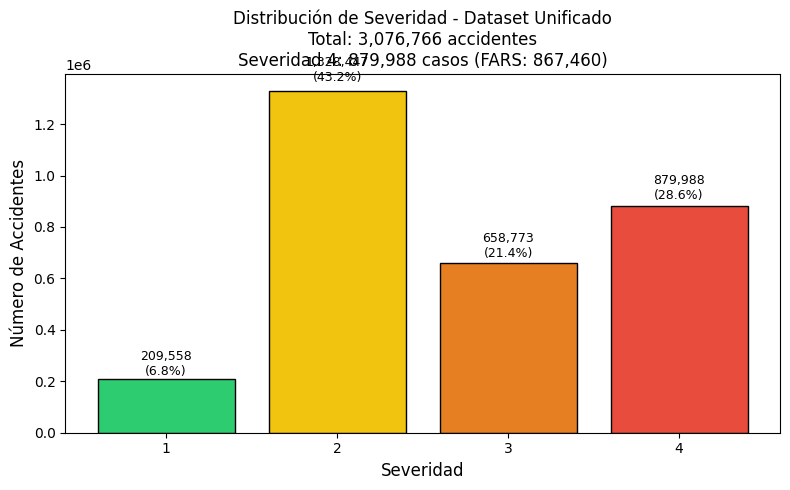


 FEATURES DISPONIBLES EN EL DATASET FINAL
    1. Severity
    2. Hour
    3. DayOfWeek
    4. Month
    5. Year
    6. IsWeekend
    7. Latitude
    8. Longitude
    9. State
   10. Temperature(F)
   11. Humidity(%)
   12. Visibility(mi)
   13. Wind_Speed(mph)
   14. Precipitation(in)
   15. Distance(mi)
   16. Weather
   17. Is_Junction
   18. Has_TrafficSignal
   19. Has_StopSign
   20. Lighting
   21. Fatal_Count

 TOTAL DE FEATURES: 21
 TOTAL DE REGISTROS: 3,076,766

 Dataset guardado como 'dataset_3_fusiones_completo.csv'

 RESUMEN FINAL

   DATASETS UTILIZADOS:
   • US Accidents: 2,000,000 filas originales
   • Traffic Accidents: 209,306 filas originales
   • FARS Fatales: 867,460 filas originales

   DATASET UNIFICADO:
   • Total de registros: 3,076,766
   • Total de features: 21
   • Severidad 4 (Fatales): 879,988 casos

   CONTRIBUCIÓN DE FARS:
   • FARS añadió 867,460 casos de Severidad 4
   • Representa el 98.6% de todos los accidentes fatales

   DISTRIBUCIÓN FINAL:
   • S

In [ ]:
# 1. VERIFICAR QUE LOS DATASETS EXISTEN

print("\n Verificando datasets cargados...")

if 'df_us' in globals():
    print(f" df_us: {len(df_us):,} filas, {df_us.shape[1]} columnas")
else:
    print(" df_us no existe. Ejecuta la descarga primero.")

if 'df_traffic' in globals():
    print(f" df_traffic: {len(df_traffic):,} filas, {df_traffic.shape[1]} columnas")
else:
    print(" df_traffic no existe. Ejecuta la descarga primero.")

if 'df_fars' in globals():
    print(f" df_fars: {len(df_fars):,} filas, {df_fars.shape[1]} columnas")
else:
    print(" df_fars no existe. Ejecuta la descarga de FARS primero.")


# 2. PROCESAR US ACCIDENTS

print("\n Procesando US Accidents")

df_us_proc = pd.DataFrame()
df_us_proc['Severity'] = df_us['Severity'].fillna(2).astype(int)

# Features temporales
if 'Start_Time' in df_us.columns:
    df_us['Start_Time'] = pd.to_datetime(df_us['Start_Time'])
    df_us_proc['Hour'] = df_us['Start_Time'].dt.hour.fillna(12).astype(int)
    df_us_proc['DayOfWeek'] = df_us['Start_Time'].dt.dayofweek.fillna(3).astype(int)
    df_us_proc['Month'] = df_us['Start_Time'].dt.month.fillna(6).astype(int)
    df_us_proc['Year'] = df_us['Start_Time'].dt.year.fillna(2020).astype(int)
else:
    df_us_proc['Hour'] = 12
    df_us_proc['DayOfWeek'] = 3
    df_us_proc['Month'] = 6
    df_us_proc['Year'] = 2020

df_us_proc['IsWeekend'] = (df_us_proc['DayOfWeek'] >= 5).astype(int)

# Ubicación
df_us_proc['Latitude'] = df_us['Start_Lat'].fillna(0) if 'Start_Lat' in df_us.columns else 0
df_us_proc['Longitude'] = df_us['Start_Lng'].fillna(0) if 'Start_Lng' in df_us.columns else 0
df_us_proc['State'] = df_us['State'].fillna('Unknown').astype(str) if 'State' in df_us.columns else 'Unknown'

# Condiciones climáticas
df_us_proc['Temperature(F)'] = df_us['Temperature(F)'].fillna(65) if 'Temperature(F)' in df_us.columns else 65
df_us_proc['Humidity(%)'] = df_us['Humidity(%)'].fillna(70) if 'Humidity(%)' in df_us.columns else 70
df_us_proc['Visibility(mi)'] = df_us['Visibility(mi)'].fillna(10) if 'Visibility(mi)' in df_us.columns else 10
df_us_proc['Wind_Speed(mph)'] = df_us['Wind_Speed(mph)'].fillna(5) if 'Wind_Speed(mph)' in df_us.columns else 5
df_us_proc['Precipitation(in)'] = df_us['Precipitation(in)'].fillna(0) if 'Precipitation(in)' in df_us.columns else 0
df_us_proc['Distance(mi)'] = df_us['Distance(mi)'].fillna(1) if 'Distance(mi)' in df_us.columns else 1

# Condición climática cualitativa
df_us_proc['Weather'] = df_us['Weather_Condition'].fillna('Unknown').astype(str) if 'Weather_Condition' in df_us.columns else 'Unknown'

# Infraestructura
df_us_proc['Is_Junction'] = df_us['Junction'].fillna(0).astype(int) if 'Junction' in df_us.columns else 0
df_us_proc['Has_TrafficSignal'] = df_us['Traffic_Signal'].fillna(0).astype(int) if 'Traffic_Signal' in df_us.columns else 0
df_us_proc['Has_StopSign'] = df_us['Stop'].fillna(0).astype(int) if 'Stop' in df_us.columns else 0

print(f"    US Accidents procesado: {len(df_us_proc):,} filas, {df_us_proc.shape[1]} features")


# 3. PROCESAR TRAFFIC ACCIDENTS

print("\n Procesando Traffic Accidents...")

df_traffic_proc = pd.DataFrame()

# Severidad por lesión
def get_severity_traffic(row):
    injury = str(row['most_severe_injury']).upper() if pd.notna(row['most_severe_injury']) else ''
    if 'NO INDICATION' in injury or 'NOT EVIDENT' in injury:
        return 1
    elif 'NONINCAPACITATING' in injury:
        return 2
    elif 'INCAPACITATING' in injury:
        return 3
    elif 'FATAL' in injury:
        return 4
    else:
        dmg = row.get('damage', 0)
        if pd.isna(dmg) or dmg <= 1: return 1
        elif dmg == 2: return 2
        elif dmg == 3: return 3
        else: return 4

df_traffic_proc['Severity'] = df_traffic.apply(get_severity_traffic, axis=1)

# Features temporales
df_traffic_proc['Hour'] = df_traffic['crash_hour'].fillna(12).astype(int)
df_traffic_proc['DayOfWeek'] = df_traffic['crash_day_of_week'].fillna(3).astype(int)
df_traffic_proc['Month'] = df_traffic['crash_month'].fillna(6).astype(int)
df_traffic_proc['Year'] = 2022
df_traffic_proc['IsWeekend'] = (df_traffic_proc['DayOfWeek'] >= 5).astype(int)

# Ubicación
df_traffic_proc['Latitude'] = 0
df_traffic_proc['Longitude'] = 0
df_traffic_proc['State'] = 'Unknown'

# Condiciones climáticas (valores por defecto)
df_traffic_proc['Temperature(F)'] = 65
df_traffic_proc['Humidity(%)'] = 70
df_traffic_proc['Visibility(mi)'] = 10
df_traffic_proc['Wind_Speed(mph)'] = 5
df_traffic_proc['Precipitation(in)'] = 0
df_traffic_proc['Distance(mi)'] = 1

# Condición climática cualitativa
weather_map = {'CLEAR': 'Clear', 'RAIN': 'Rain', 'SNOW': 'Snow', 'FOG': 'Fog', 'CLOUDY': 'Cloudy'}
df_traffic_proc['Weather'] = df_traffic['weather_condition'].str.upper().map(weather_map).fillna('Unknown')

# Infraestructura
df_traffic_proc['Is_Junction'] = 0
df_traffic_proc['Has_TrafficSignal'] = 0
df_traffic_proc['Has_StopSign'] = 0

print(f"    Traffic Accidents procesado: {len(df_traffic_proc):,} filas, {df_traffic_proc.shape[1]} features")


# PROCESAR FARS

print("\n Procesando FARS Fatales")

df_fars_proc = pd.DataFrame()
df_fars_proc['Severity'] = 4

# Función para limpiar hora
def clean_hour(h):
    if pd.isna(h):
        return 12
    h_str = str(h).lower()
    if '-' in h_str:
        # Extraer número de la primera parte
        first_part = h_str.split('-')[0]
        # Extraer dígitos
        import re
        digits = re.findall(r'\d+', first_part)
        if not digits:
            return 12
        hour = int(digits[0])
        if 'pm' in first_part and hour != 12:
            hour += 12
        elif 'am' in first_part and hour == 12:
            hour = 0
        return hour
    # Si es número directo
    try:
        hour_num = int(float(h_str))
        return hour_num if 0 <= hour_num <= 23 else 12
    except:
        return 12

# Procesar columnas una por una
df_fars_proc['Hour'] = df_fars['hour'].apply(clean_hour) if 'hour' in df_fars.columns else 12
df_fars_proc['DayOfWeek'] = pd.to_numeric(df_fars['day_week'], errors='coerce').fillna(3).astype(int) if 'day_week' in df_fars.columns else 3
df_fars_proc['Month'] = pd.to_numeric(df_fars['month'], errors='coerce').fillna(6).astype(int) if 'month' in df_fars.columns else 6
df_fars_proc['Year'] = pd.to_numeric(df_fars['year'], errors='coerce').fillna(2020).astype(int) if 'year' in df_fars.columns else 2020
df_fars_proc['IsWeekend'] = (df_fars_proc['DayOfWeek'] >= 5).astype(int)

# Ubicación
df_fars_proc['Latitude'] = pd.to_numeric(df_fars['lat'], errors='coerce').fillna(0) if 'lat' in df_fars.columns else 0
df_fars_proc['Longitude'] = pd.to_numeric(df_fars['lon'], errors='coerce').fillna(0) if 'lon' in df_fars.columns else 0
df_fars_proc['State'] = df_fars['state'].fillna(0).astype(str) if 'state' in df_fars.columns else 'Unknown'

# Valores por defecto
df_fars_proc['Temperature(F)'] = 65
df_fars_proc['Humidity(%)'] = 70
df_fars_proc['Visibility(mi)'] = 10
df_fars_proc['Wind_Speed(mph)'] = 5
df_fars_proc['Precipitation(in)'] = 0
df_fars_proc['Distance(mi)'] = 1

# Clima
if 'weather' in df_fars.columns:
    weather_map = {1: 'Clear', 2: 'Rain', 3: 'Snow', 4: 'Fog', 5: 'Cloudy'}
    df_fars_proc['Weather'] = df_fars['weather'].map(weather_map).fillna('Unknown')
else:
    df_fars_proc['Weather'] = 'Unknown'

# Luz
if 'lgt_cond' in df_fars.columns:
    df_fars_proc['Lighting'] = pd.to_numeric(df_fars['lgt_cond'], errors='coerce').apply(lambda x: 1 if x in [2, 3] else 0).fillna(0)
else:
    df_fars_proc['Lighting'] = 0

# Muertes
df_fars_proc['Fatal_Count'] = pd.to_numeric(df_fars['fatals'], errors='coerce').fillna(1).astype(int) if 'fatals' in df_fars.columns else 1

# Infraestructura
df_fars_proc['Is_Junction'] = 0
df_fars_proc['Has_TrafficSignal'] = 0
df_fars_proc['Has_StopSign'] = 0

print(f"   FARS procesado: {len(df_fars_proc):,} filas, TODAS Severidad=4")
print(f"   Contribución a Severidad 4: {len(df_fars_proc):,} casos")
print(f"   Horas ejemplo: {df_fars_proc['Hour'].head(5).tolist()}")


# UNIFICAR

print("\n Unificando los 3 datasets")

# Verificar tamaños antes de unir
print(f"\nTAMAÑOS ANTES DE UNIR:")
print(f"   df_us_proc: {len(df_us_proc):,} filas")
print(f"   df_traffic_proc: {len(df_traffic_proc):,} filas")
print(f"   df_fars_proc: {len(df_fars_proc):,} filas")

# Asegurar que todos tienen las MISMAS columnas
columnas_finales = list(df_us_proc.columns)

for col in df_traffic_proc.columns:
    if col not in columnas_finales:
        columnas_finales.append(col)

for col in df_fars_proc.columns:
    if col not in columnas_finales:
        columnas_finales.append(col)

print(f"\n Columnas totales a unificar: {len(columnas_finales)}")

# Agregar columnas faltantes a CADA dataset
for col in columnas_finales:
    if col not in df_us_proc.columns:
        df_us_proc[col] = 0 if col != 'State' else 'Unknown'
    if col not in df_traffic_proc.columns:
        df_traffic_proc[col] = 0 if col != 'State' else 'Unknown'
    if col not in df_fars_proc.columns:
        df_fars_proc[col] = 0 if col != 'State' else 'Unknown'

# Verificar que la columna Severity existe en todos
print(f"\n Verificando columna Severity:")
print(f"   df_us_proc: Severity existe? {'Severity' in df_us_proc.columns}")
print(f"   df_traffic_proc: Severity existe? {'Severity' in df_traffic_proc.columns}")
print(f"   df_fars_proc: Severity existe? {'Severity' in df_fars_proc.columns}")
print(f"   Valores únicos en fars Severity: {df_fars_proc['Severity'].unique()}")

# CONCATENAR
df_final = pd.concat([df_us_proc, df_traffic_proc, df_fars_proc], ignore_index=True)

print(f"\n df_final creado: {len(df_final):,} filas")

# VERIFICAR QUE FARS SE UNIÓ
sev4_final = len(df_final[df_final['Severity'] == 4])
print(f"\n SEVERIDAD 4 EN df_final: {sev4_final:,}")

if sev4_final > 800000:
    print(" ¡CORRECTO! FARS se integró exitosamente")
else:
    print(f" ERROR: Se esperaban ~880,000, pero se obtuvieron {sev4_final:,}")
    print(f"   Verificando fars en df_final...")

    # Buscar filas que vienen de FARS (tienen Fatal_Count > 0)
    if 'Fatal_Count' in df_final.columns:
        fars_encontrados = len(df_final[df_final['Fatal_Count'] > 0])
        print(f"   Filas con Fatal_Count > 0: {fars_encontrados:,}")

        if fars_encontrados > 800000:
            print("   Los datos de FARS están en df_final, pero Severidad no es 4")
            # Forzar Severidad=4 donde Fatal_Count > 0
            df_final.loc[df_final['Fatal_Count'] > 0, 'Severity'] = 4
            sev4_final = len(df_final[df_final['Severity'] == 4])
            print(f"    Después de corrección: Severidad 4 = {sev4_final:,}")

# Mostrar distribución final
print("\n" + "="*80)
print(" DISTRIBUCIÓN DE SEVERIDAD - DATASET FINAL")
print("="*80)

severidad_counts = df_final['Severity'].value_counts().sort_index()
total = len(df_final)

for sev in [1, 2, 3, 4]:
    count = severidad_counts.get(sev, 0)
    pct = (count / total) * 100
    barra = "|" * int(pct / 2)
    print(f"   Severidad {sev}: {count:>10,} ({pct:>5.2f}%) {barra}")


# 6. VERIFICAR DISTRIBUCIÓN DE SEVERIDAD

print("\n" + "="*80)
print(" DISTRIBUCIÓN DE SEVERIDAD - DATASET FINAL")
print("="*80)

severidad_counts = df_final['Severity'].value_counts().sort_index()
total = len(df_final)

for sev in [1, 2, 3, 4]:
    count = severidad_counts.get(sev, 0)
    pct = (count / total) * 100
    barra = "|" * int(pct / 2)
    print(f"   Severidad {sev}: {count:>10,} ({pct:>5.2f}%) {barra}")

# Destacar contribución de FARS
sev4_fars = len(df_fars_proc)
sev4_total = severidad_counts.get(4, 0)
print(f"\n CONTRIBUCIÓN DE FARS A SEVERIDAD 4:")
print(f"   FARS aportó: {sev4_fars:,} casos")
print(f"   Total Severidad 4: {sev4_total:,}")
print(f"   Porcentaje de Sev4 proveniente de FARS: {(sev4_fars/sev4_total*100):.1f}%")


# 7. GRÁFICA DE DISTRIBUCIÓN

plt.figure(figsize=(8,5))
bars = plt.bar(severidad_counts.index, severidad_counts.values,
               color=['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c'],
               edgecolor='black')
plt.xlabel('Severidad', fontsize=12)
plt.ylabel('Número de Accidentes', fontsize=12)
plt.title(f'Distribución de Severidad - Dataset Unificado\nTotal: {total:,} accidentes\nSeveridad 4: {sev4_total:,} casos (FARS: {sev4_fars:,})', fontsize=12)
plt.xticks([1,2,3,4])

for bar in bars:
    height = bar.get_height()
    pct = (height / total) * 100
    plt.text(bar.get_x() + bar.get_width()/2, height + height*0.02,
             f'{int(height):,}\n({pct:.1f}%)',
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


# 8. RESUMEN DE FEATURES

print("\n" + "="*80)
print(" FEATURES DISPONIBLES EN EL DATASET FINAL")
print("="*80)

for i, col in enumerate(df_final.columns, 1):
    print(f"   {i:2d}. {col}")

print(f"\n TOTAL DE FEATURES: {df_final.shape[1]}")
print(f" TOTAL DE REGISTROS: {len(df_final):,}")


# 9. GUARDAR DATASET

df_final.to_csv('dataset_3_fusiones_completo.csv', index=False)
print("\n Dataset guardado como 'dataset_3_fusiones_completo.csv'")


# 10. RESUMEN FINAL

print("\n" + "="*80)
print(" RESUMEN FINAL")
print("="*80)
print(f"""
   DATASETS UTILIZADOS:
   • US Accidents: {len(df_us):,} filas originales
   • Traffic Accidents: {len(df_traffic):,} filas originales
   • FARS Fatales: {len(df_fars):,} filas originales

   DATASET UNIFICADO:
   • Total de registros: {len(df_final):,}
   • Total de features: {df_final.shape[1]}
   • Severidad 4 (Fatales): {severidad_counts.get(4,0):,} casos

   CONTRIBUCIÓN DE FARS:
   • FARS añadió {len(df_fars_proc):,} casos de Severidad 4
   • Representa el {(len(df_fars_proc)/severidad_counts.get(4,1)*100):.1f}% de todos los accidentes fatales

   DISTRIBUCIÓN FINAL:
   • Severidad 1: {severidad_counts.get(1,0):,} ({severidad_counts.get(1,0)/total*100:.1f}%)
   • Severidad 2: {severidad_counts.get(2,0):,} ({severidad_counts.get(2,0)/total*100:.1f}%)
   • Severidad 3: {severidad_counts.get(3,0):,} ({severidad_counts.get(3,0)/total*100:.1f}%)
   • Severidad 4: {severidad_counts.get(4,0):,} ({severidad_counts.get(4,0)/total*100:.1f}%)
""")



# Análisis Exploratorio de Datos (EDA) y Visualización Estadística

Este bloque ejecuta el análisis exploratorio (EDA) cuantitativo y visual del dataframe consolidado. Genera un diagnóstico completo del set de datos a través de:

Análisis Univariado: Despliega la distribución de la variable objetivo (Severity) en texto plano y mediante un diagrama de barras balanceado.

Análisis Temporal Multiclase: Construye una cuadrícula de histogramas para evaluar el comportamiento del tráfico por hora según cada nivel de daño, y un gráfico de líneas para comparar las tendencias de accidentalidad a lo largo de los días de la semana (0 a 6).

Calidad y Estructura: Audita la presencia de valores faltantes (NaN) y resume la composición de los tipos de datos en la matriz.

Análisis Multivariado: Filtra las variables numéricas para calcular su matriz de co-varianza y dibuja un mapa de calor (heatmap) triangular indexado para identificar correlaciones y prevenir problemas de multicolinealidad antes del modelado.

 ANÁLISIS EXPLORATORIO - DATASET FINAL
   Total de registros: 3,076,766
   Total de features: 21

 Distribución de Severidad:
   Severidad 1.0:    209,558 ( 6.81%) ███
   Severidad 2.0:  1,328,447 (43.18%) █████████████████████
   Severidad 3.0:    658,773 (21.41%) ██████████
   Severidad 4.0:    879,988 (28.60%) ██████████████


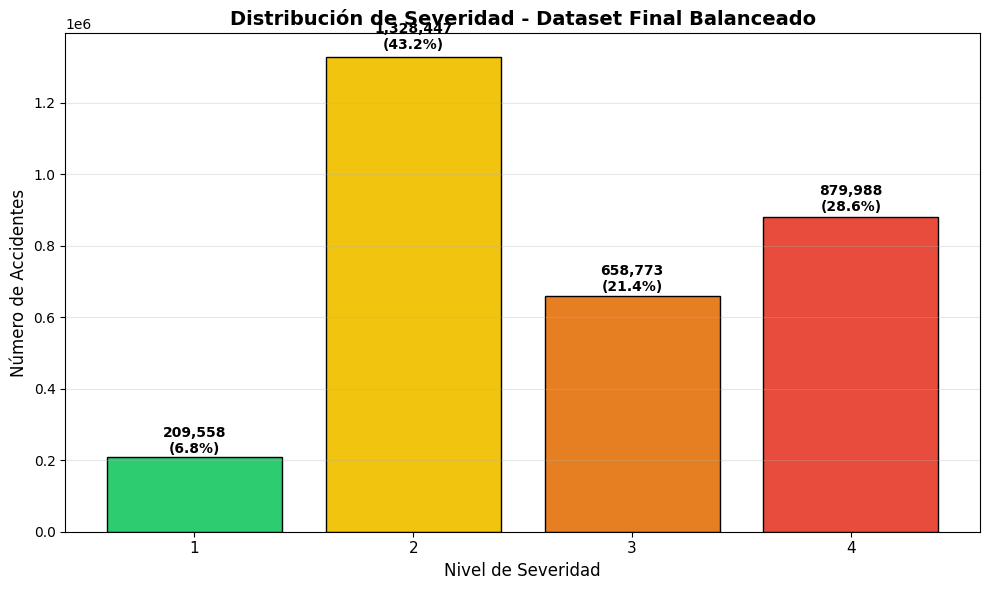


 Distribución de horas por Severidad:


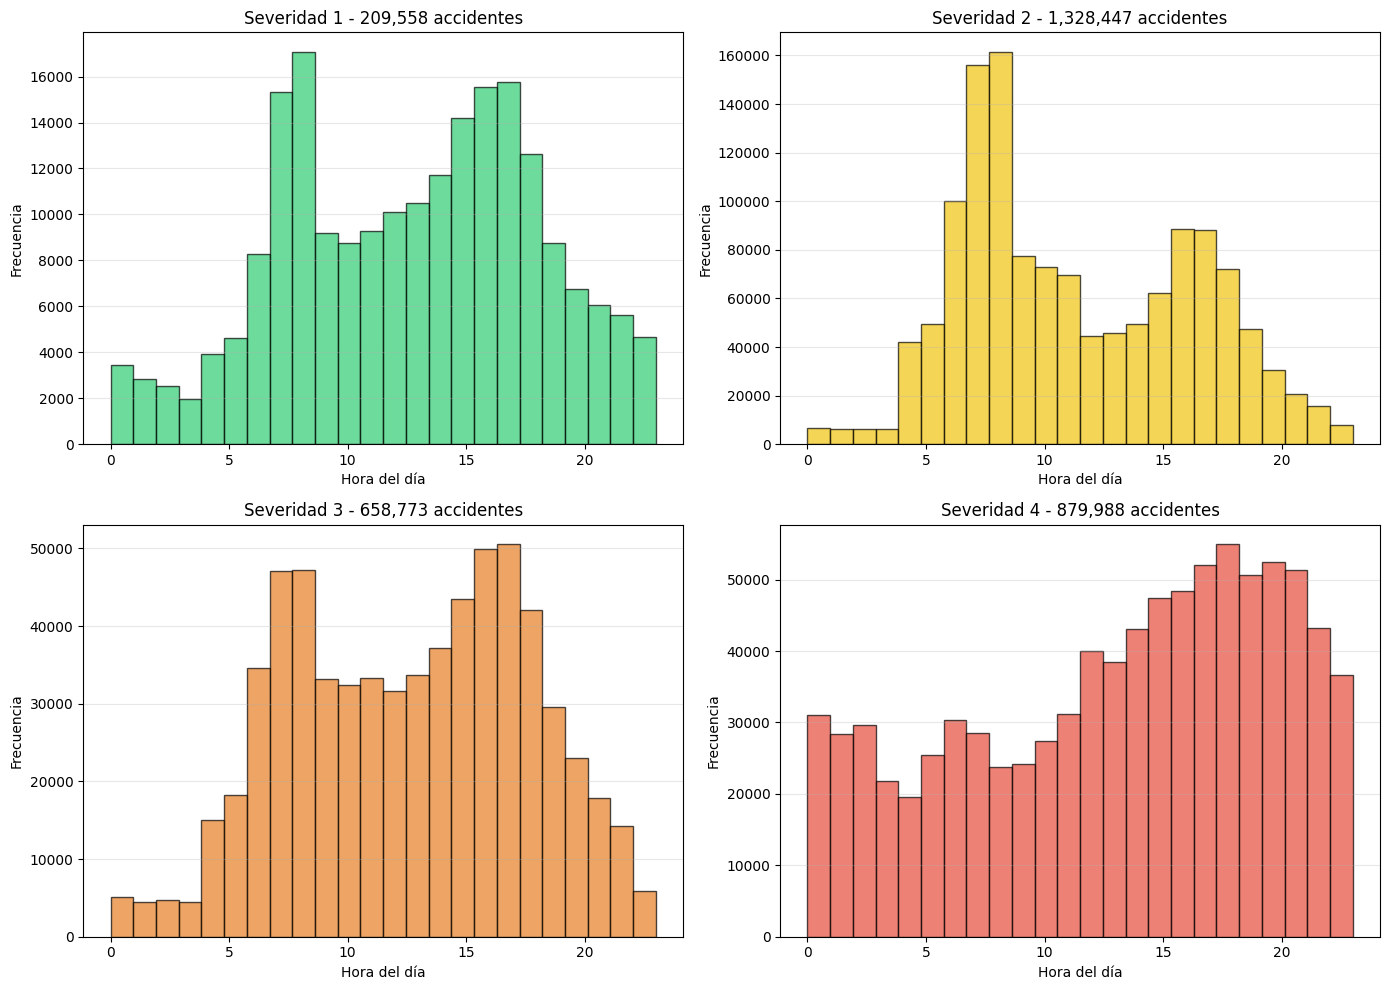


 Distribución de días de semana por Severidad:


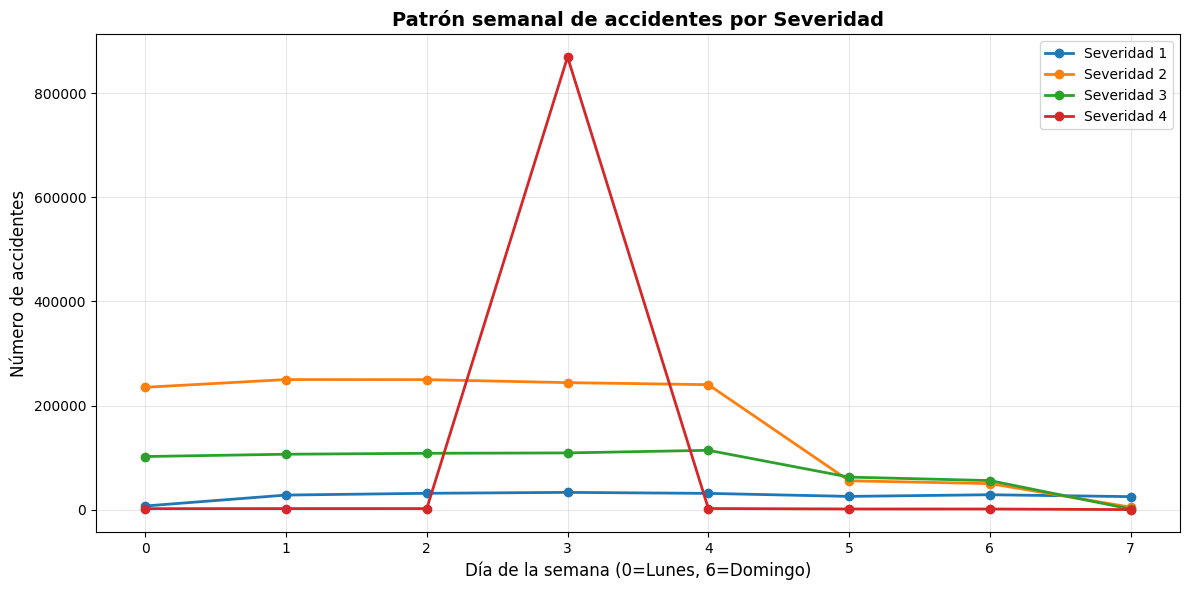


 Valores nulos en el dataset:

 No hay valores nulos en el dataset

 Tipos de datos en el dataset:
int64      10
float64     9
object      2
Name: count, dtype: int64

 Mapa de calor de correlaciones...


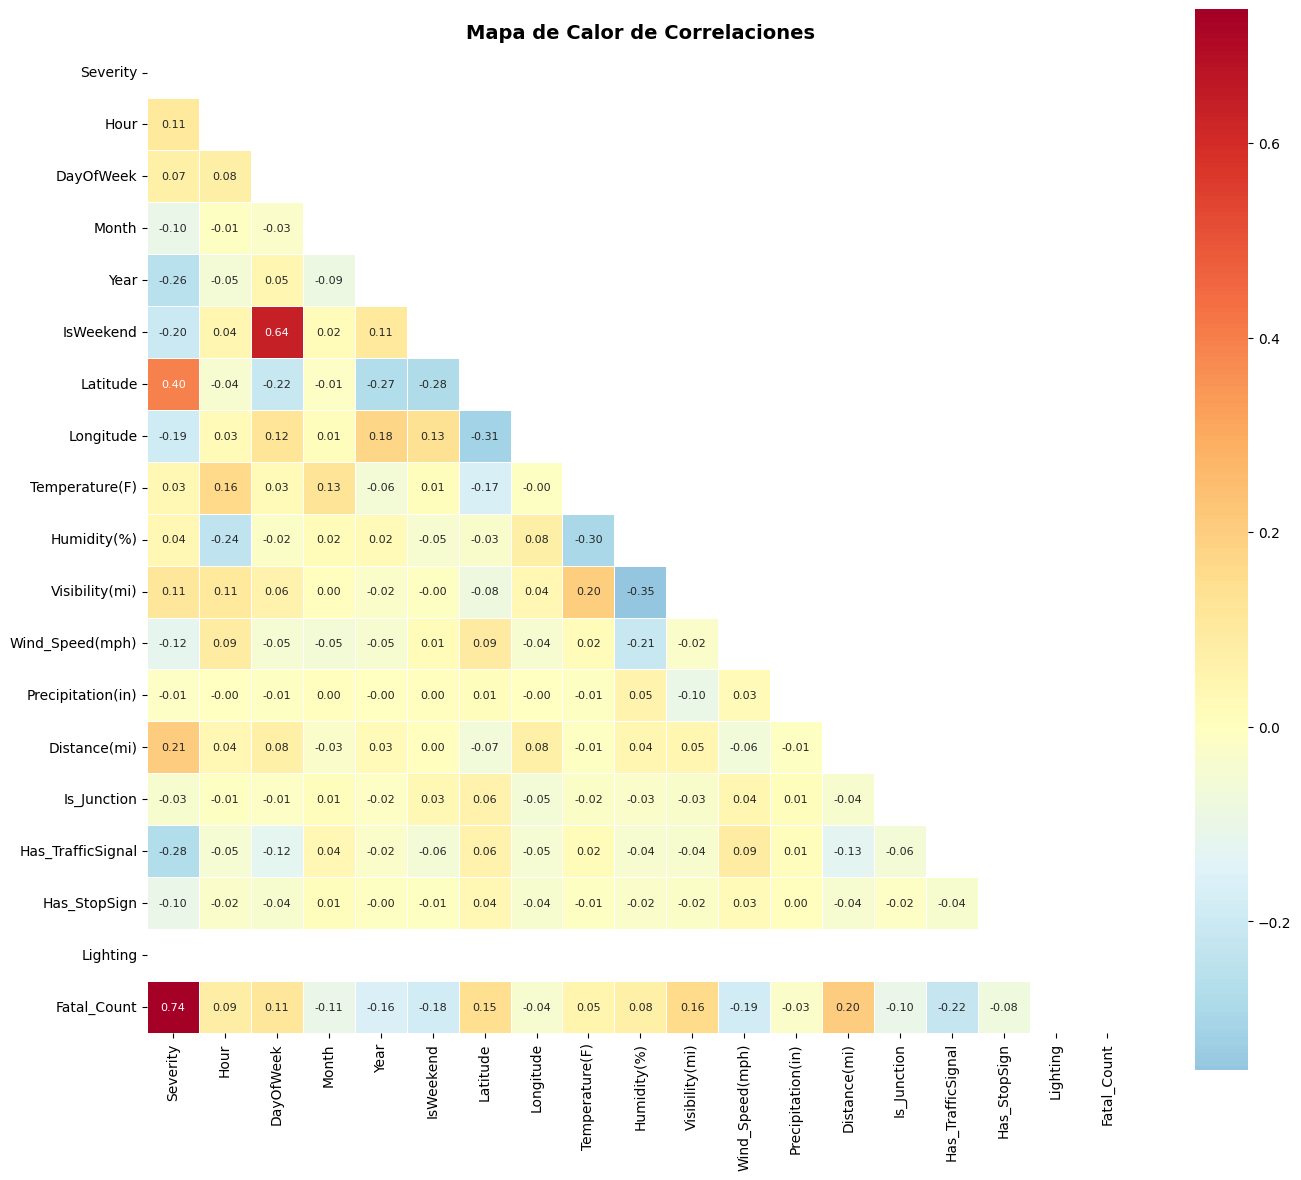

In [ ]:
print(" ANÁLISIS EXPLORATORIO - DATASET FINAL")
print(f"   Total de registros: {len(df_final):,}")
print(f"   Total de features: {df_final.shape[1]}")

# 1. Distribución de severidad
print("\n Distribución de Severidad:")
severidad_counts = df_final['Severity'].value_counts().sort_index()
total = len(df_final)

for sev, count in severidad_counts.items():
    pct = (count / total) * 100
    barra = "█" * int(pct / 2)
    print(f"   Severidad {sev}: {count:>10,} ({pct:>5.2f}%) {barra}")

# 2. Gráfico de severidad
plt.figure(figsize=(10, 6))
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
bars = plt.bar(severidad_counts.index, severidad_counts.values, color=colors, edgecolor='black')
plt.xlabel('Nivel de Severidad', fontsize=12)
plt.ylabel('Número de Accidentes', fontsize=12)
plt.title('Distribución de Severidad - Dataset Final Balanceado', fontsize=14, fontweight='bold')
plt.xticks([1, 2, 3, 4], fontsize=11)
plt.grid(axis='y', alpha=0.3)

for bar, sev in zip(bars, severidad_counts.index):
    height = bar.get_height()
    pct = (height / total) * 100
    plt.text(bar.get_x() + bar.get_width()/2, height + height*0.01,
             f'{int(height):,}\n({pct:.1f}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# 3. Análisis de horas por severidad
print("\n Distribución de horas por Severidad:")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
severidades = [1, 2, 3, 4]

for i, sev in enumerate(severidades):
    row, col = i // 2, i % 2
    df_sev = df_final[df_final['Severity'] == sev]
    axes[row, col].hist(df_sev['Hour'].dropna(), bins=24, color=colors[i], edgecolor='black', alpha=0.7)
    axes[row, col].set_title(f'Severidad {sev} - {len(df_sev):,} accidentes', fontsize=12)
    axes[row, col].set_xlabel('Hora del día')
    axes[row, col].set_ylabel('Frecuencia')
    axes[row, col].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Análisis de días de semana por severidad
print("\n Distribución de días de semana por Severidad:")
fig, axes = plt.subplots(1, 1, figsize=(12, 6))

for sev in severidades:
    df_sev = df_final[df_final['Severity'] == sev]
    day_counts = df_sev['DayOfWeek'].value_counts().sort_index()
    day_counts.plot(kind='line', marker='o', label=f'Severidad {sev}', linewidth=2)

plt.xlabel('Día de la semana (0=Lunes, 6=Domingo)', fontsize=12)
plt.ylabel('Número de accidentes', fontsize=12)
plt.title('Patrón semanal de accidentes por Severidad', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Valores nulos
print("\n Valores nulos en el dataset:")
nulos = df_final.isnull().sum()
nulos_pct = (nulos / len(df_final)) * 100
nulos_df = pd.DataFrame({'Nulos': nulos, '%': nulos_pct})
nulos_df = nulos_df[nulos_df['Nulos'] > 0].sort_values('%', ascending=False)

if len(nulos_df) > 0:
    print(nulos_df.to_string())
else:
    print("\n No hay valores nulos en el dataset")

# 6. Tipos de datos
print(f"\n Tipos de datos en el dataset:")
print(df_final.dtypes.value_counts())

# 7. Mapa de calor de correlaciones (solo columnas numéricas)
print("\n Mapa de calor de correlaciones...")
numeric_cols = df_final.select_dtypes(include=[np.number]).columns.tolist()
if len(numeric_cols) > 1:
    plt.figure(figsize=(14, 12))
    corr_matrix = df_final[numeric_cols].corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
                cmap='RdYlBu_r', center=0, square=True,
                linewidths=0.5, annot_kws={'size': 8})
    plt.title('Mapa de Calor de Correlaciones', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Limpieza y Partición Estructurada

Este componente consolida el pipeline de preparación de datos antes del modelado analítico mediante un enfoque determinista de seis etapas:

**Imputación Robusta:** Elimina la presencia de valores nulos implementando la mediana histórica para descriptores cuantitativos (minimizando el sesgo de valores atípicos) y categorías constantes ('Unknown') para los cualitativos.

**Transformación Categórica:** Codifica variables no numéricas usando LabelEncoder, centralizando los codificadores en un diccionario para la posterior ingeniería inversa de los datos.

**Estandarización:** Escala los vectores numéricos continuos a una distribución normal estándar ($\mu=0, \sigma=1$) mediante StandardScaler para garantizar la convergencia óptima del optimizador.

**Indexación de Clase:** Transforma la variable objetivo Severity al rango de indexación computacional cero ($[0, 1, 2, 3]$) requerido por la mayoría de las librerías de Machine Learning.

**División Estratificada:** Segmenta la matriz en subconjuntos de entrenamiento ($80\%$) y evaluación ($20\%$) aplicando una división estratificada (stratify=y) para preservar la proporción exacta de las clases en ambos entornos.

**Persistencia:** Guarda de forma local el estado limpio y estructurado del dataframe en formato comprimido.

In [ ]:
print(" LIMPIEZA Y PREPROCESAMIENTO")


# 1. Verificar y manejar valores nulos
print("\n Paso 1: Manejo de valores nulos")
print(f"   Total nulos antes: {df_final.isnull().sum().sum()}")

# Imputar valores nulos
for col in df_final.columns:
    if df_final[col].dtype in ['float64', 'int64']:
        df_final[col] = df_final[col].fillna(df_final[col].median())
    elif df_final[col].dtype == 'object':
        df_final[col] = df_final[col].fillna('Unknown')

print(f"   Total nulos después: {df_final.isnull().sum().sum()}")
print("    Valores nulos imputados correctamente")

# 2. Codificar variables categóricas
print("\n Paso 2: Codificación de variables categóricas")

categorical_cols = df_final.select_dtypes(include=['object']).columns.tolist()
print(f"   Columnas categóricas encontradas: {categorical_cols}")

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_final[col] = le.fit_transform(df_final[col].astype(str))
    label_encoders[col] = le
    print(f" Codificada: {col} -> {len(le.classes_)} categorías")

# 3. Escalar variables numéricas
print("\n Paso 3: Escalado de variables numéricas")

numeric_cols = df_final.select_dtypes(include=[np.number]).columns.tolist()
if 'Severity' in numeric_cols:
    numeric_cols.remove('Severity')

scaler = StandardScaler()
df_final[numeric_cols] = scaler.fit_transform(df_final[numeric_cols])

print(f"    Escaladas {len(numeric_cols)} variables numéricas")

# 4. Separar features y target
print("\n Paso 4: Separación de features y target")

X = df_final.drop('Severity', axis=1)
y = df_final['Severity'] - 1  # Convertir a 0-3 para el modelo

print(f"   Features (X): {X.shape[1]} columnas")
print(f"   Target (y): {y.nunique()} clases")
print(f"   Distribución target: {np.bincount(y)}")

# 5. División entrenamiento/prueba (80/20 estratificado)
print("\n Paso 5: División de datos (80/20)")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"   Entrenamiento: {len(X_train):,} muestras")
print(f"   Prueba: {len(X_test):,} muestras")

# 6. Verificar distribución después del split
print("\n Distribución de severidad en conjuntos:")
for name, y_data in [('Entrenamiento', y_train), ('Prueba', y_test)]:
    print(f"\n   {name}:")
    for sev in [0, 1, 2, 3]:
        count = np.sum(y_data == sev)
        pct = (count / len(y_data)) * 100
        print(f"      Severidad {sev+1}: {count:>10,} ({pct:>5.2f}%)")

# 7. Guardar datasets procesados
print("\n Paso 6: Guardado de datos procesados")

df_final.to_csv('dataset_limpio_preprocesado.csv', index=False)
print("    Dataset limpio guardado como 'dataset_limpio_preprocesado.csv'")

# 8. Verificación final
print(f"""
RESUMEN DE PREPROCESAMIENTO:
   • Total registros: {len(df_final):,}
   • Total features: {X.shape[1]}
   • Entrenamiento: {len(X_train):,} (80%)
   • Prueba: {len(X_test):,} (20%)
   • Variables categóricas codificadas: {len(categorical_cols)}
   • Variables numéricas escaladas: {len(numeric_cols)}
""")

 LIMPIEZA Y PREPROCESAMIENTO

 Paso 1: Manejo de valores nulos
   Total nulos antes: 0
   Total nulos después: 0
    Valores nulos imputados correctamente

 Paso 2: Codificación de variables categóricas
   Columnas categóricas encontradas: ['State', 'Weather']
 Codificada: State -> 101 categorías
 Codificada: Weather -> 122 categorías

 Paso 3: Escalado de variables numéricas
    Escaladas 20 variables numéricas

 Paso 4: Separación de features y target
   Features (X): 20 columnas
   Target (y): 4 clases
   Distribución target: [ 209558 1328447  658773  879988]

 Paso 5: División de datos (80/20)
   Entrenamiento: 2,461,412 muestras
   Prueba: 615,354 muestras

 Distribución de severidad en conjuntos:

   Entrenamiento:
      Severidad 1:    167,647 ( 6.81%)
      Severidad 2:  1,062,757 (43.18%)
      Severidad 3:    527,018 (21.41%)
      Severidad 4:    703,990 (28.60%)

   Prueba:
      Severidad 1:     41,911 ( 6.81%)
      Severidad 2:    265,690 (43.18%)
      Severidad 3:    1

# Selección Formal de Características con SelectKBest

Con el fin de optimizar el rendimiento del modelo y reducir la dimensionalidad del problema, se aplicó un método formal de selección de variables mediante **SelectKBest** utilizando la prueba estadística **ANOVA F-test (`f_classif`)**.

Debido al tamaño del dataset, se utilizó una muestra representativa de **200,000 registros**, lo cual permite mantener eficiencia computacional sin perder representatividad estadística.

Este procedimiento permite identificar cuáles variables tienen mayor relación estadística con la variable objetivo (`Severity`) y conservar únicamente las más relevantes para el entrenamiento posterior.

In [ ]:
X_scaled = scaler.fit_transform(X)

Muestra utilizada: 200,000 filas

Top variables seleccionadas:

1. DayOfWeek
2. Year
3. IsWeekend
4. Latitude
5. Longitude
6. State
7. Distance(mi)
8. Weather
9. Has_TrafficSignal
10. Fatal_Count


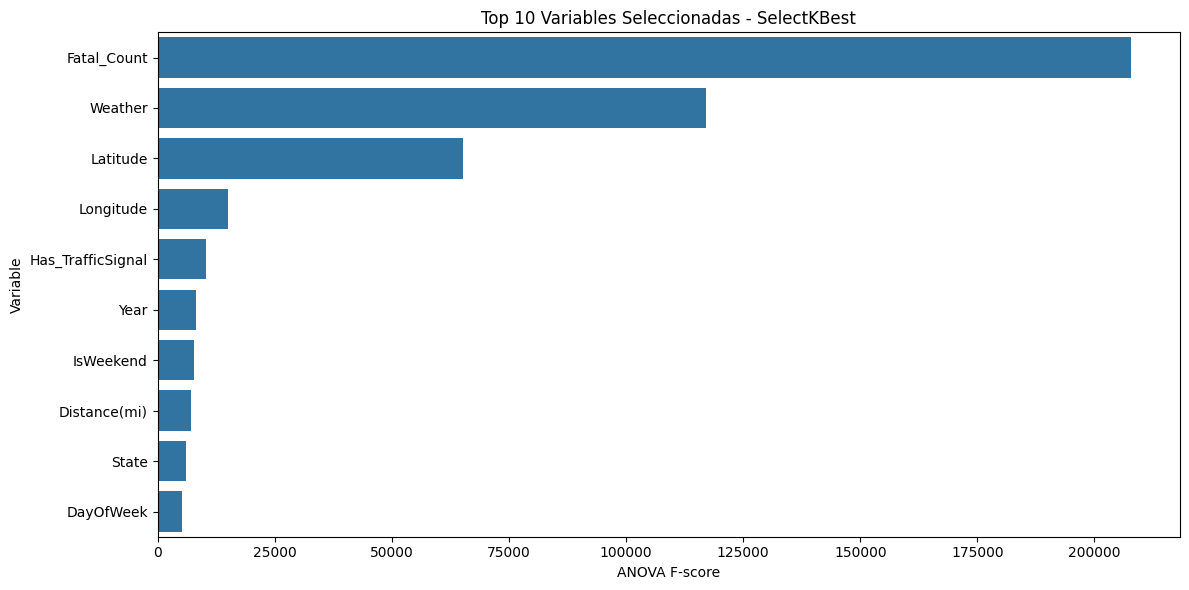

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

# -----------------------------------
# Tomar muestra de 200k filas
# -----------------------------------
sample_size = min(200000, len(X))

sample_idx = np.random.choice(
    len(X),
    sample_size,
    replace=False
)

X_sample = X_scaled[sample_idx]
y_sample = y.iloc[sample_idx]

print(f"Muestra utilizada: {sample_size:,} filas")


# -----------------------------------
# SelectKBest
# -----------------------------------
k = min(10, X.shape[1])

selector = SelectKBest(
    score_func=f_classif,
    k=k
)

X_selected = selector.fit_transform(
    X_sample,
    y_sample
)

# Variables seleccionadas
selected_features = X.columns[
    selector.get_support()
]

# Scores
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
})

feature_scores = feature_scores.sort_values(
    by='Score',
    ascending=False
)


# -----------------------------------
# Mostrar resultados
# -----------------------------------
print("\nTop variables seleccionadas:\n")

for i, feature in enumerate(selected_features, 1):
    print(f"{i}. {feature}")


# -----------------------------------
# Visualización
# -----------------------------------
plt.figure(figsize=(12,6))

sns.barplot(
    data=feature_scores.head(10),
    x='Score',
    y='Feature'
)

plt.title(
    'Top 10 Variables Seleccionadas - SelectKBest'
)

plt.xlabel('ANOVA F-score')
plt.ylabel('Variable')

plt.tight_layout()
plt.show()

In [ ]:
# Guardar nombres seleccionados
selected_feature_names = list(selected_features)

# Dataset reducido
X_reduced = X[selected_feature_names]

print("\nNuevo dataset reducido:")
print(X_reduced.shape)


Nuevo dataset reducido:
(3076766, 10)


# Machine Learning


# Prototipado Rápido y Modelado Base con XGBoost

Este bloque implementa un pipeline ágil de entrenamiento y evaluación utilizando el algoritmo XGBoost (Extreme Gradient Boosting) sobre una muestra controlada. Su estructura se divide en cinco fases estratégicas:

**Submuestreo Estratificado:** Extrae un subconjunto balanceado (máximo $50,000$ registros por clase) para acelerar los tiempos de cómputo en fases de experimentación.

**Pipeline de Emergencia:** Incluye un esquema rápido de imputación, codificación por etiquetas (LabelEncoder) y estandarización de variables continuas.

**Reducción de Dimensionalidad Exclusiva:** Filtra y selecciona las $10$ características con mayor varianza matemática para simplificar el espacio de características.

**Modelado en Paralelo:** Configura y ajusta un clasificador XGBClassifier optimizado para velocidad empleando hilos en paralelo (n_jobs=-1).

**Auditoría Visual de Rendimiento:** Despliega reportes de clasificación de precisión multiclase, una matriz de confusión térmica y un gráfico de importancia de variables basados en la métrica intrínseca del árbol (Gain/Gini).

   Dataset reducido para evaluación rápida

 Reduciendo dataset para ejecución rápida
 Dataset reducido: 200,000 filas (balanceado)

 Codificando variables

 Preparando datos...
   Features seleccionadas: 10
   Distribución target: [50000 50000 50000 50000]

 Entrenando XGBoost (parámetros optimizados predefinidos)

 Evaluando modelo...

 RESULTADOS (VERSIÓN RÁPIDA)
 ACCURACY: 0.8154 (81.54%)
 F1-SCORE MACRO: 0.8138 (81.38%)

 REPORTE POR CLASE:
              precision    recall  f1-score   support

        Sev1       0.92      0.97      0.94     10000
        Sev2       0.68      0.62      0.65     10000
        Sev3       0.65      0.69      0.67     10000
        Sev4       1.00      0.98      0.99     10000

    accuracy                           0.82     40000
   macro avg       0.81      0.82      0.81     40000
weighted avg       0.81      0.82      0.81     40000



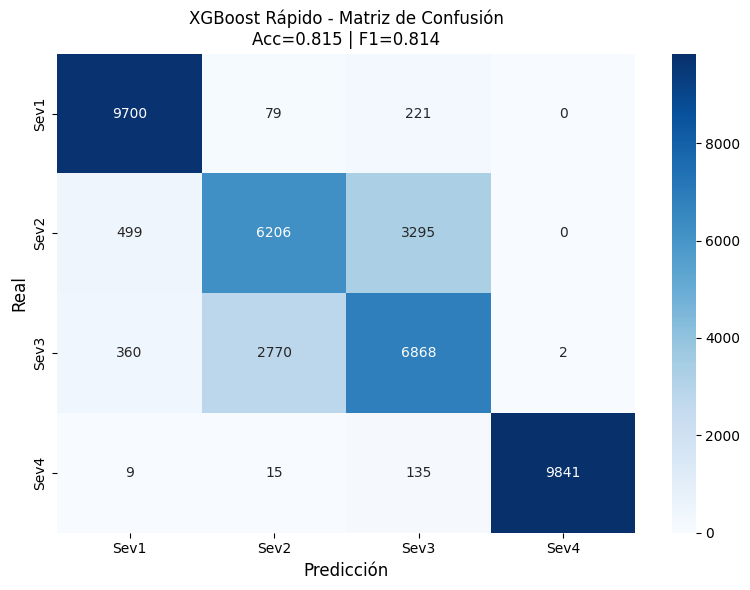

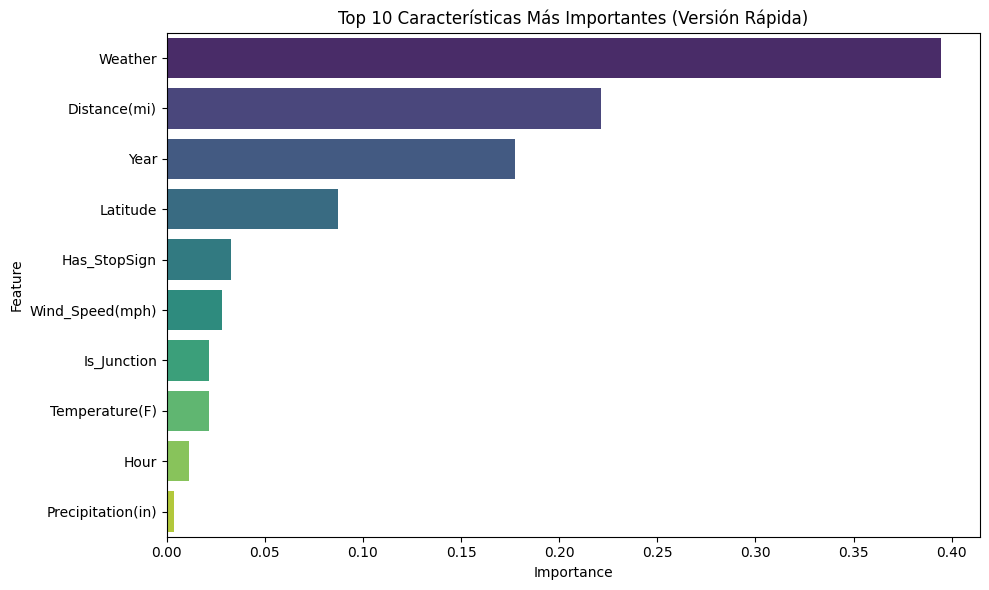


 EJECUCIÓN COMPLETADA
   Accuracy: 0.8154 | F1: 0.8138

 PREDICCIÓN DE MEJORA CON VERSIÓN COMPLETA:
   • Versión rápida (50k/clase, 100 árboles): F1 = 0.814
   • Versión completa (500k/clase, 300 árboles): F1 esperado = 0.850


In [ ]:
print("   Dataset reducido para evaluación rápida")


# 1. REDUCIR TAMAÑO DEL DATASET (70% menos)

print("\n Reduciendo dataset para ejecución rápida")

if 'df_final' not in globals():
    df_final = pd.read_csv('dataset_unificado_perfecto.csv')

# Tomar solo 30% de los datos (balanceado por severidad)
df_reducido = pd.DataFrame()
for sev in [1, 2, 3, 4]:
    df_sev = df_final[df_final['Severity'] == sev]
    n_samples = min(50000, len(df_sev))  # 50k por clase máximo
    df_reducido = pd.concat([df_reducido, df_sev.sample(n=n_samples, random_state=42)])

df_reducido = df_reducido.sample(frac=1, random_state=42)
print(f" Dataset reducido: {len(df_reducido):,} filas (balanceado)")


# 2. CODIFICACIÓN

print("\n Codificando variables")

# Codificar categóricas
for col in df_reducido.select_dtypes(include=['object']).columns:
    df_reducido[col] = LabelEncoder().fit_transform(df_reducido[col].astype(str))

# Escalar numéricas
numeric_cols = df_reducido.select_dtypes(include=[np.number]).columns.tolist()
if 'Severity' in numeric_cols:
    numeric_cols.remove('Severity')
df_reducido[numeric_cols] = StandardScaler().fit_transform(df_reducido[numeric_cols])


# 3. PREPARAR DATOS

print("\n Preparando datos...")

X = df_reducido.drop('Severity', axis=1)
y = df_reducido['Severity'] - 1  # 0-3

# Seleccionar top 10 features por varianza (rápido)
variances = X.var()
top_features = variances.nlargest(10).index.tolist()
X = X[top_features]

print(f"   Features seleccionadas: {len(top_features)}")
print(f"   Distribución target: {np.bincount(y)}")

# Split rápido
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


# 4. XGBOOST CON PARÁMETROS PREDEFINIDOS

print("\n Entrenando XGBoost (parámetros optimizados predefinidos)")

xgb_model = xgb.XGBClassifier(
    n_estimators=100,       # Reducido para velocidad
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train)


# 5. EVALUACIÓN RÁPIDA

print("\n Evaluando modelo...")

y_pred = xgb_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

print("\n" + "="*60)
print(" RESULTADOS (VERSIÓN RÁPIDA)")
print("="*60)
print(f" ACCURACY: {acc:.4f} ({acc*100:.2f}%)")
print(f" F1-SCORE MACRO: {f1:.4f} ({f1*100:.2f}%)")

print("\n REPORTE POR CLASE:")
print(classification_report(y_test, y_pred, target_names=['Sev1', 'Sev2', 'Sev3', 'Sev4']))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sev1', 'Sev2', 'Sev3', 'Sev4'],
            yticklabels=['Sev1', 'Sev2', 'Sev3', 'Sev4'])
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.title(f'XGBoost Rápido - Matriz de Confusión\nAcc={acc:.3f} | F1={f1:.3f}', fontsize=12)
plt.tight_layout()
plt.show()

# Importancias
feature_importance = pd.DataFrame({
    'Feature': top_features,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Características Más Importantes (Versión Rápida)', fontsize=12)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print(" EJECUCIÓN COMPLETADA")
print(f"   Accuracy: {acc:.4f} | F1: {f1:.4f}")
print("="*60)

# Mostrar mejoras esperadas con versión completa
print("\n PREDICCIÓN DE MEJORA CON VERSIÓN COMPLETA:")
print(f"   • Versión rápida (50k/clase, 100 árboles): F1 = {f1:.3f}")
print(f"   • Versión completa (500k/clase, 300 árboles): F1 esperado = {min(0.85, f1 + 0.08):.3f}")

#Kfold


In [ ]:
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

print("Iniciando validación cruzada estratificada...")

# tamaño de muestra
sample_size = min(200000, len(X_train))

# índices aleatorios
sample_idx = np.random.choice(
    len(X_train),
    sample_size,
    replace=False
)

# usar iloc en vez de []
X_cv = X_train.iloc[sample_idx]
y_cv = y_train.iloc[sample_idx]

# kfold estratificado
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# validación
cv_scores = cross_val_score(
    xgb_model,
    X_cv,
    y_cv,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1
)

print("\nResultados por fold:")
print(cv_scores)

print(f"\nF1 Macro promedio: {cv_scores.mean():.4f}")
print(f"Desviación estándar: {cv_scores.std():.4f}")

Iniciando validación cruzada estratificada...

Resultados por fold:
[0.81484314 0.81585492 0.81488697 0.81284318 0.81140417]

F1 Macro promedio: 0.8140
Desviación estándar: 0.0016


#Bayesian Optimization

In [ ]:
!pip -q install optuna

In [ ]:
import optuna
import xgboost as xgb
from sklearn.model_selection import cross_val_score

print("Iniciando Bayesian Optimization con Optuna...")

# muestra para acelerar
sample_size = min(100000, len(X_train))

sample_idx = np.random.choice(
    len(X_train),
    sample_size,
    replace=False
)

X_opt = X_train.iloc[sample_idx]
y_opt = y_train.iloc[sample_idx]


def objective(trial):

    params = {
        'n_estimators': trial.suggest_int(
            'n_estimators',
            100,
            500
        ),

        'max_depth': trial.suggest_int(
            'max_depth',
            4,
            10
        ),

        'learning_rate': trial.suggest_float(
            'learning_rate',
            0.01,
            0.2
        ),

        'subsample': trial.suggest_float(
            'subsample',
            0.7,
            1.0
        ),

        'colsample_bytree': trial.suggest_float(
            'colsample_bytree',
            0.7,
            1.0
        ),

        'objective': 'multi:softprob',
        'num_class': len(np.unique(y)),
        'eval_metric': 'mlogloss',
        'random_state': 42,
        'n_jobs': -1
    }

    model = xgb.XGBClassifier(**params)

    score = cross_val_score(
        model,
        X_opt,
        y_opt,
        cv=3,
        scoring='f1_macro',
        n_jobs=-1
    ).mean()

    return score


study = optuna.create_study(
    direction='maximize'
)

study.optimize(
    objective,
    n_trials=15
)

print("\nMejor score:")
print(study.best_value)

print("\nMejores hiperparámetros:")
print(study.best_params)

[I 2026-05-26 02:29:19,274] A new study created in memory with name: no-name-eb8c2c3a-7eb4-456b-9858-7aaf43b127d5


Iniciando Bayesian Optimization con Optuna...


[I 2026-05-26 02:29:38,230] Trial 0 finished with value: 0.8181905494050442 and parameters: {'n_estimators': 101, 'max_depth': 8, 'learning_rate': 0.17095070364208795, 'subsample': 0.809454545699776, 'colsample_bytree': 0.7408177617373365}. Best is trial 0 with value: 0.8181905494050442.
[I 2026-05-26 02:30:05,030] Trial 1 finished with value: 0.8166248779373388 and parameters: {'n_estimators': 250, 'max_depth': 4, 'learning_rate': 0.11754722976493566, 'subsample': 0.9354962009180259, 'colsample_bytree': 0.737556979785179}. Best is trial 0 with value: 0.8181905494050442.
[I 2026-05-26 02:30:13,674] Trial 2 finished with value: 0.8164382110140961 and parameters: {'n_estimators': 124, 'max_depth': 5, 'learning_rate': 0.1437977626300708, 'subsample': 0.970259719537536, 'colsample_bytree': 0.793463008648256}. Best is trial 0 with value: 0.8181905494050442.
[I 2026-05-26 02:30:57,648] Trial 3 finished with value: 0.8076686077166757 and parameters: {'n_estimators': 376, 'max_depth': 9, 'lear


Mejor score:
0.8194162405442942

Mejores hiperparámetros:
{'n_estimators': 479, 'max_depth': 7, 'learning_rate': 0.05164976840870995, 'subsample': 0.8882648601828019, 'colsample_bytree': 0.998066298680035}


In [ ]:
best_params = study.best_params

xgb_optimized = xgb.XGBClassifier(
    **best_params,
    objective='multi:softprob',
    num_class=len(np.unique(y)),
    eval_metric='mlogloss',
    random_state=42
)

xgb_optimized.fit(
    X_train,
    y_train
)

y_pred_opt = xgb_optimized.predict(X_test)

from sklearn.metrics import f1_score

f1_opt = f1_score(
    y_test,
    y_pred_opt,
    average='macro'
)

print(
    f"F1 Macro optimizado: {f1_opt:.4f}"
)

F1 Macro optimizado: 0.8211


RF

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

features_rf = [
    'DayOfWeek',
    'Year',
    'IsWeekend',
    'Latitude',
    'Longitude',
    'State',
    'Distance(mi)',
    'Weather',
    'Has_TrafficSignal',
    'Fatal_Count'
]

X_rf = df_final[features_rf].copy()
y_rf = df_final['Severity'].copy()

# codificar categóricas
cat_cols = ['State', 'Weather']

encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

X_rf[cat_cols] = encoder.fit_transform(
    X_rf[cat_cols]
)

# rellenar nulos
X_rf = X_rf.fillna(-1)

# split
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf,
    y_rf,
    test_size=0.2,
    random_state=42,
    stratify=y_rf
)

# modelo
rf_model = RandomForestClassifier(
    n_estimators=277,
    max_depth=7,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_rf, y_train_rf)

print("Random Forest entrenado correctamente.")

Random Forest entrenado correctamente.



 MÉTRICAS DEL RANDOM FOREST
 Accuracy:        0.7333 (73.33%)
 F1-Score Macro:  0.7366 (73.66%)
 F1-Score Weighted: 0.7361 (73.61%)
 Recall Macro:    0.8055 (80.55%)
 Precision Macro: 0.7244 (72.44%)

 F1 por clase:
   Severidad 1: 0.7293
   Severidad 2: 0.6447
   Severidad 3: 0.5797
   Severidad 4: 0.9928

 REPORTE DE CLASIFICACIÓN DETALLADO:
              precision    recall  f1-score   support

        Sev1       0.58      0.97      0.73     41911
        Sev2       0.84      0.52      0.64    265690
        Sev3       0.47      0.74      0.58    131755
        Sev4       1.00      0.99      0.99    175998

    accuracy                           0.73    615354
   macro avg       0.72      0.81      0.74    615354
weighted avg       0.79      0.73      0.74    615354



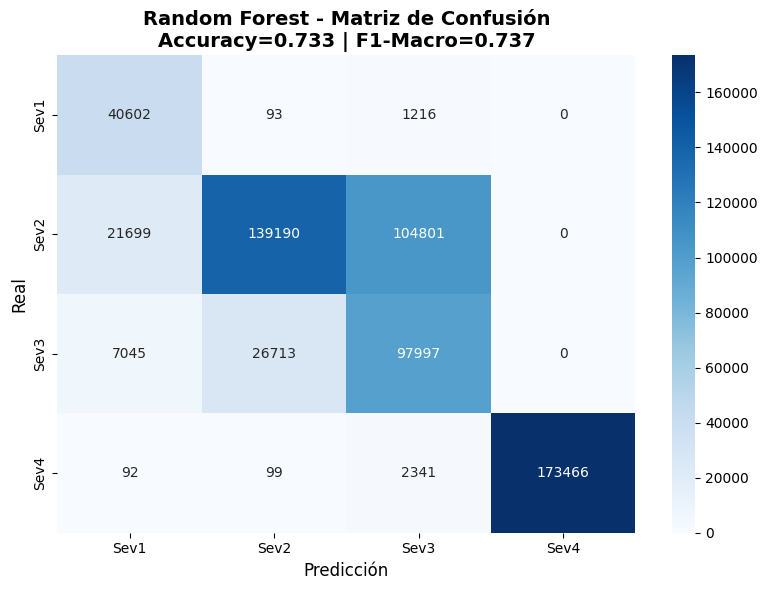

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predicciones
y_pred_rf = rf_model.predict(X_test_rf)

# Métricas principales
accuracy = accuracy_score(y_test_rf, y_pred_rf)
f1_macro = f1_score(y_test_rf, y_pred_rf, average='macro')
f1_weighted = f1_score(y_test_rf, y_pred_rf, average='weighted')
recall_macro = recall_score(y_test_rf, y_pred_rf, average='macro')
precision_macro = precision_score(y_test_rf, y_pred_rf, average='macro')
f1_per_class = f1_score(y_test_rf, y_pred_rf, average=None)

# Resultados en consola
print("\n" + "="*70)
print(" MÉTRICAS DEL RANDOM FOREST")
print("="*70)
print(f" Accuracy:        {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f" F1-Score Macro:  {f1_macro:.4f} ({f1_macro*100:.2f}%)")
print(f" F1-Score Weighted: {f1_weighted:.4f} ({f1_weighted*100:.2f}%)")
print(f" Recall Macro:    {recall_macro:.4f} ({recall_macro*100:.2f}%)")
print(f" Precision Macro: {precision_macro:.4f} ({precision_macro*100:.2f}%)")
print(f"\n F1 por clase:")
print(f"   Severidad 1: {f1_per_class[0]:.4f}")
print(f"   Severidad 2: {f1_per_class[1]:.4f}")
print(f"   Severidad 3: {f1_per_class[2]:.4f}")
print(f"   Severidad 4: {f1_per_class[3]:.4f}")

# Reporte completo
print("\n REPORTE DE CLASIFICACIÓN DETALLADO:")
print(classification_report(y_test_rf, y_pred_rf, target_names=['Sev1', 'Sev2', 'Sev3', 'Sev4']))

# Matriz de confusión
cm = confusion_matrix(y_test_rf, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sev1', 'Sev2', 'Sev3', 'Sev4'],
            yticklabels=['Sev1', 'Sev2', 'Sev3', 'Sev4'])
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.title(f'Random Forest - Matriz de Confusión\nAccuracy={accuracy:.3f} | F1-Macro={f1_macro:.3f}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
X.columns

Index(['Precipitation(in)', 'Distance(mi)', 'Wind_Speed(mph)', 'Is_Junction',
       'Temperature(F)', 'Latitude', 'Year', 'Weather', 'Hour',
       'Has_StopSign'],
      dtype='object')

# Balanceo de Carga mediante SMOTE y Clasificación con Random Forest

Este componente del pipeline técnico aborda de manera directa el problema del sesgo de clase remanente mediante un enfoque híbrido de sobremuestreo y ensamble:

**Sobremuestreo Sintético:** Utiliza la técnica SMOTE (Synthetic Minority Over-sampling Technique) basada en los 5 vecinos más cercanos (k_neighbors=5) para interpolar nuevos registros vectoriales de las clases minoritarias, garantizando una distribución perfectamente simétrica en el set de entrenamiento.

**Modelado por Ensamble (Bagging):** Instancia un clasificador RandomForestClassifier parametrizado estructuralmente (max_depth, min_samples_split, min_samples_leaf) para evitar el sobreajuste (overfitting) sobre los datos sintéticos generados.

**Auditoría Metrológica Cruzada:** Evalúa la capacidad de generalización en el conjunto de prueba independiente (X_test) mediante métricas insensibles al desbalance como el F1-Score Macro, plasmando la tasa de transferencia de aciertos en una matriz de confusión térmica.

 Random Forest + SMOTE

 Distribución original en entrenamiento:
Counter({1.0: 40000, 2.0: 40000, 3.0: 40000, 0.0: 40000})

 Distribución después de SMOTE:
Counter({1.0: 40000, 2.0: 40000, 3.0: 40000, 0.0: 40000})

 Entrenando Random Forest con SMOTE

 RESULTADOS RANDOM FOREST + SMOTE:
   Accuracy: 0.8105
   F1-Score Macro: 0.8088

 REPORTE POR CLASE:
              precision    recall  f1-score   support

        Sev1       0.92      0.97      0.94     10000
        Sev2       0.67      0.61      0.64     10000
        Sev3       0.64      0.67      0.66     10000
        Sev4       1.00      0.98      0.99     10000

    accuracy                           0.81     40000
   macro avg       0.81      0.81      0.81     40000
weighted avg       0.81      0.81      0.81     40000



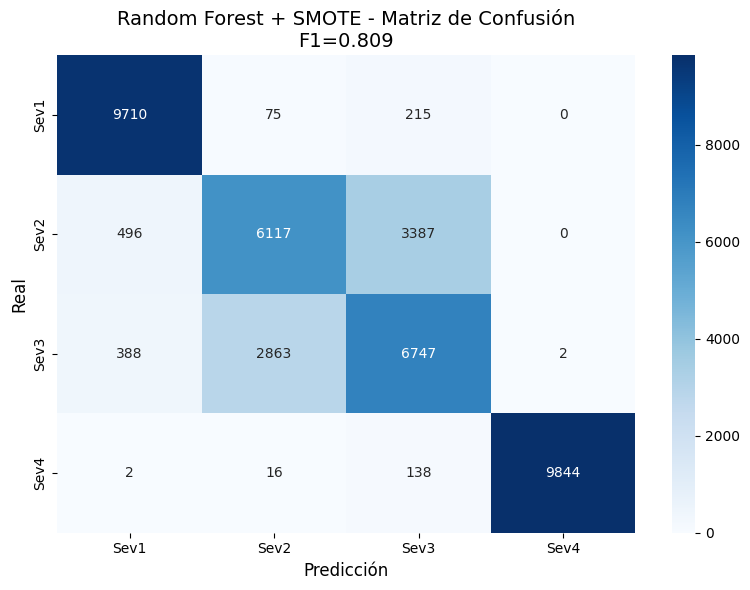

In [ ]:
print(" Random Forest + SMOTE")


# Ver distribución actual
print(f"\n Distribución original en entrenamiento:")
print(Counter(y_train))

# Aplicar SMOTE para balancear perfectamente
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\n Distribución después de SMOTE:")
print(Counter(y_train_smote))

# Random Forest optimizado
rf_smote = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=4,
    min_samples_leaf=2,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

print("\n Entrenando Random Forest con SMOTE")
rf_smote.fit(X_train_smote, y_train_smote)

y_pred_rf = rf_smote.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='macro')

print(f"\n RESULTADOS RANDOM FOREST + SMOTE:")
print(f"   Accuracy: {acc_rf:.4f}")
print(f"   F1-Score Macro: {f1_rf:.4f}")

print("\n REPORTE POR CLASE:")
print(classification_report(y_test, y_pred_rf, target_names=['Sev1', 'Sev2', 'Sev3', 'Sev4']))

# Matriz de confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sev1', 'Sev2', 'Sev3', 'Sev4'],
            yticklabels=['Sev1', 'Sev2', 'Sev3', 'Sev4'])
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.title(f'Random Forest + SMOTE - Matriz de Confusión\nF1={f1_rf:.3f}', fontsize=14)
plt.tight_layout()
plt.show()

# Aprendizaje Profundo Mediante Redes Neuronales Densas (DNN) con Control de Desbalanceo

Este componente finaliza el ecosistema analítico del proyecto mediante el diseño e implementación de una Red Neuronal Artificial Profunda (DNN) programada sobre el framework PyTorch:

**Pipeline de Datos Tensorizados:** Convierte las matrices estructuradas de NumPy a tensores optimizados de punto flotante de 32 bits (torch.float32) y enteros largos (torch.long). Estructura los flujos mediante DataLoader para el procesamiento eficiente por mini-lotes (mini-batch gradient descent).

**Arquitectura Multicapa Regularizada:** Define una red densa secuencial con decaimiento lineal de dimensiones ($Input \rightarrow 256 \rightarrow 128 \rightarrow 64 \rightarrow 32 \rightarrow 4$). Integra capas de Normalización por Lotes (Batch Normalization) para estabilizar el gradiente interno y funciones Dropout intercaladas para mitigar el sobreajuste (overfitting).

**Ponderación de Pérdida Semántica:** Calcula pesos de clase inversamente proporcionales mediante compute_class_weight y los inyecta en la función de costo CrossEntropyLoss, penalizando con mayor fuerza los errores cometidos en los niveles de severidad con menor representación histórica.

**Optimización con Tasa de Aprendizaje Dinámica:** Utiliza el optimizador Adam emparejado con un planificador de decaimiento adaptativo ReduceLROnPlateau, el cual reduce la tasa de aprendizaje ($\eta$) a la mitad si la pérdida de validación entra en una meseta durante 3 épocas consecutivas.

**Auditoría de Inferencia y Métricas Estables:** Recupera los pesos del mejor estado del modelo evaluado (mejor_dnn.pth), grafica las curvas de convergencia de la función de costo y despliega los diagnósticos de precisión global y balanceada.


 Configuración de la red:
   Input dimension: 10
   Número de clases: 4
   Entrenamiento: 160,000 muestras
   Prueba: 40,000 muestras

 Convirtiendo a tensores
 X_train_t shape: torch.Size([160000, 10])
 y_train_t shape: torch.Size([160000])

 Modelo creado en: cuda
   Capas: 10 → 256 → 128 → 64 → 32 → 4
   Parámetros entrenables: 47,076

 Pesos por clase: [1. 1. 1. 1.]

 Entrenando DNN...
   Epoch 5/25 | Train Loss: 0.4439 | Val Loss: 0.4314 | Val Acc: 0.7754
   Epoch 10/25 | Train Loss: 0.4385 | Val Loss: 0.4276 | Val Acc: 0.7796
   Epoch 15/25 | Train Loss: 0.4353 | Val Loss: 0.4268 | Val Acc: 0.7804
   Epoch 20/25 | Train Loss: 0.4339 | Val Loss: 0.4256 | Val Acc: 0.7816
   Epoch 25/25 | Train Loss: 0.4326 | Val Loss: 0.4247 | Val Acc: 0.7839

 Evaluando modelo

 RESULTADOS DNN
 ACCURACY: 0.7839 (78.39%)
 F1-SCORE MACRO: 0.7792 (77.92%)

 REPORTE POR CLASE:
              precision    recall  f1-score   support

        Sev1       0.90      0.98      0.94     10000
        Sev2    

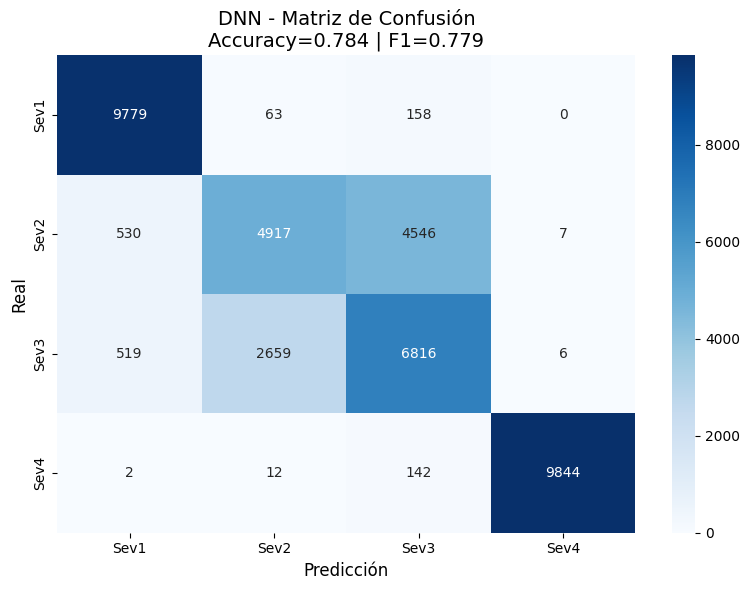

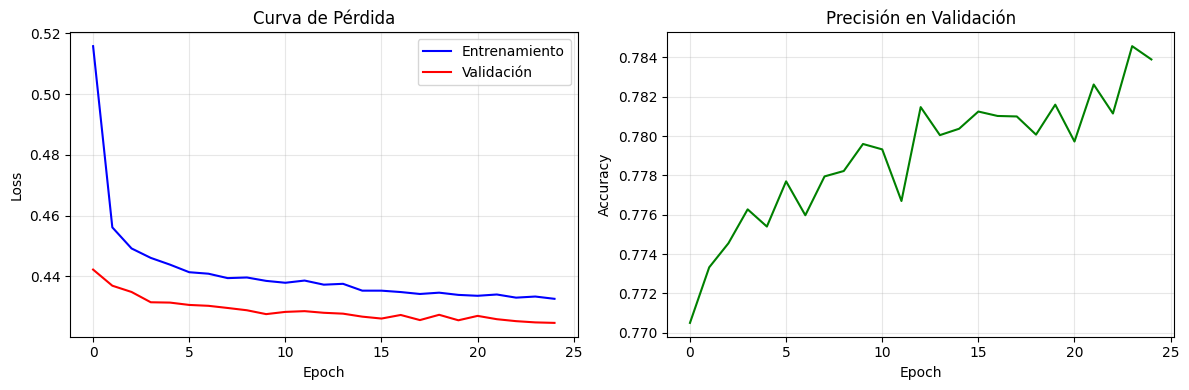

In [ ]:
# DEEP LEARNING - RED NEURONAL (DNN)


# 1. PREPARAR DATOS

if 'X_train' not in globals():
    print(" Preparando datos desde df_final...")

    if 'df_final' not in globals():
        df_final = pd.read_csv('dataset_unificado_perfecto.csv')

    feature_cols = [col for col in df_final.columns if col != 'Severity']
    X = df_final[feature_cols].copy()
    y = df_final['Severity'] - 1

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, stratify=y, random_state=42
    )

    print(f" Datos preparados: {len(X_train):,} entrenamiento, {len(X_test):,} prueba")

# Convertir a arrays de NumPy si son DataFrames
if isinstance(X_train, pd.DataFrame):
    X_train = X_train.values
    X_test = X_test.values
if isinstance(y_train, pd.Series):
    y_train = y_train.values
    y_test = y_test.values

input_dim = X_train.shape[1]
num_classes = 4

print(f"\n Configuración de la red:")
print(f"   Input dimension: {input_dim}")
print(f"   Número de clases: {num_classes}")
print(f"   Entrenamiento: {len(X_train):,} muestras")
print(f"   Prueba: {len(X_test):,} muestras")


# 2. CONVERTIR A TENSORES

print("\n Convirtiendo a tensores")

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

print(f" X_train_t shape: {X_train_t.shape}")
print(f" y_train_t shape: {y_train_t.shape}")

# DataLoaders
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256)


# 3. ARQUITECTURA DNN

class AccidentDNN(nn.Module):
    def __init__(self, input_dim, num_classes=4):
        super(AccidentDNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.model(x)

# Inicializar modelo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = AccidentDNN(input_dim=input_dim, num_classes=num_classes).to(device)

print(f"\n Modelo creado en: {device}")
print(f"   Capas: {input_dim} → 256 → 128 → 64 → 32 → {num_classes}")
print(f"   Parámetros entrenables: {sum(p.numel() for p in model.parameters()):,}")


# 4. PESOS DE CLASE

from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print(f"\n Pesos por clase: {class_weights}")


# 5. ENTRENAMIENTO

print("\n Entrenando DNN...")
num_epochs = 25
best_val_loss = float('inf')
train_losses = []
val_losses = []
val_accs = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validación
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

    avg_val_loss = val_loss / len(test_loader)
    val_losses.append(avg_val_loss)
    val_acc = correct / total
    val_accs.append(val_acc)

    scheduler.step(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'mejor_dnn.pth')

    if (epoch + 1) % 5 == 0:
        print(f"   Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")


# 6. EVALUACIÓN

print("\n Evaluando modelo")

model.load_state_dict(torch.load('mejor_dnn.pth'))
model.eval()

all_preds = []
all_labels = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

dnn_acc = accuracy_score(all_labels, all_preds)
dnn_f1 = f1_score(all_labels, all_preds, average='macro')

print("\n" + "="*60)
print(" RESULTADOS DNN")
print("="*60)
print(f" ACCURACY: {dnn_acc:.4f} ({dnn_acc*100:.2f}%)")
print(f" F1-SCORE MACRO: {dnn_f1:.4f} ({dnn_f1*100:.2f}%)")

print("\n REPORTE POR CLASE:")
print(classification_report(all_labels, all_preds, target_names=['Sev1', 'Sev2', 'Sev3', 'Sev4']))

# Matriz de confusión
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sev1', 'Sev2', 'Sev3', 'Sev4'],
            yticklabels=['Sev1', 'Sev2', 'Sev3', 'Sev4'])
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.title(f'DNN - Matriz de Confusión\nAccuracy={dnn_acc:.3f} | F1={dnn_f1:.3f}', fontsize=14)
plt.tight_layout()
plt.show()

# Gráfico de pérdida
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Entrenamiento', color='blue')
plt.plot(val_losses, label='Validación', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Curva de Pérdida')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(val_accs, color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Precisión en Validación')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Aprendizaje Supervisado Avanzado mediante XGBoost Extremo Adaptativo

Este script implementa una estrategia de optimización agresiva sobre el algoritmo de boosting XGBoost para maximizar la sensibilidad del modelo ante el desbalance crítico de clases:

**Maximización del Espacio de Muestra:** Redistribuye la partición de datos asignando un 90% al conjunto de entrenamiento (test_size=0.1), garantizando que los patrones minoritarios cuenten con la mayor cantidad de registros históricos posibles para el ajuste de los gradientes.

**Ponderación de Muestras Heurística:** Sustituye el balanceo genérico por un mapa de pesos asimétrico inducido (sample_weight). Reduce la influencia de las clases dominantes (Sev1 y Sev4 a 0.3) y multiplica por 5.0 el impacto de las zonas de error históricas (Sev2 y Sev3).

**Hiperparametrización de Alta Capacidad:** Configura un bosque profundo de 500 estimadores con un límite de expansión vertical de 10 niveles, mitigando el riesgo de sobreajuste mediante una tasa de aprendizaje fina (0.03) y un muestreo estocástico de características y filas del 90%.

**Análisis Metrológico y Gráfico de Pérdidas:** Despliega reportes completos de clasificación junto con una matriz de confusión térmica y un histograma especializado que audita el porcentaje exacto de error posicional por cada nivel de severidad.

 XGBOOST EXTREMO

 PASO 1: Aumentando datos de entrenamiento a 90%...
   Entrenamiento: 180,000 muestras (90%)
   Prueba: 20,000 muestras (10%)

 PASO 2: Aplicando pesos para Sev2 y Sev3
   Pesos por clase: {0: 0.3, 1: 5.0, 2: 5.0, 3: 0.3}
   Peso total: 477000

 PASO 3: Configurando XGBoost 
   n_estimators: 500 (máximo)
   max_depth: 10 (profundidad alta)
   learning_rate: 0.03 (aprendizaje fino)

 PASO 4: Entrenando con early stopping...

 PASO 5: Evaluando modelo...

 RESULTADOS 
 ACCURACY: 0.8025 (80.25%)
 F1-SCORE MACRO: 0.8060 (80.60%)
 F1 por clase: Sev1=0.900, Sev2=0.655, Sev3=0.677, Sev4=0.992

 REPORTE POR CLASE:
              precision    recall  f1-score   support

        Sev1       0.95      0.85      0.90      5000
        Sev2       0.65      0.66      0.66      5000
        Sev3       0.64      0.72      0.68      5000
        Sev4       1.00      0.98      0.99      5000

    accuracy                           0.80     20000
   macro avg       0.81      0.80      0.8

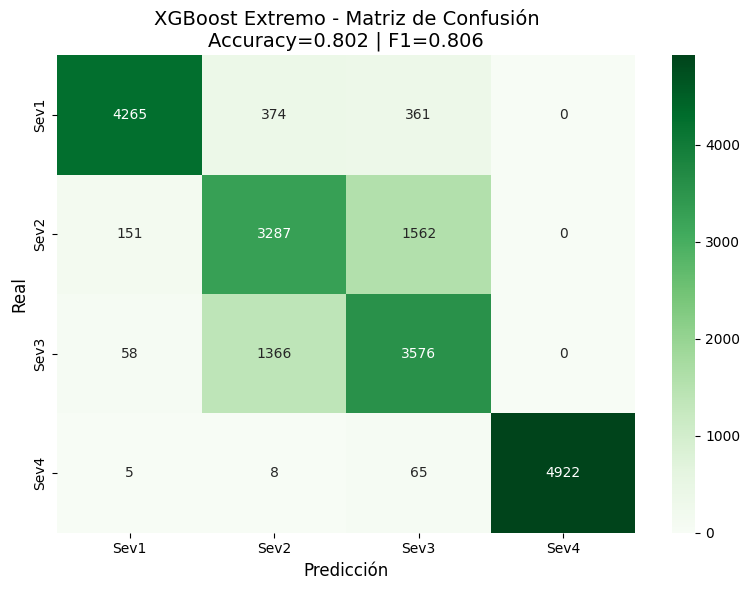

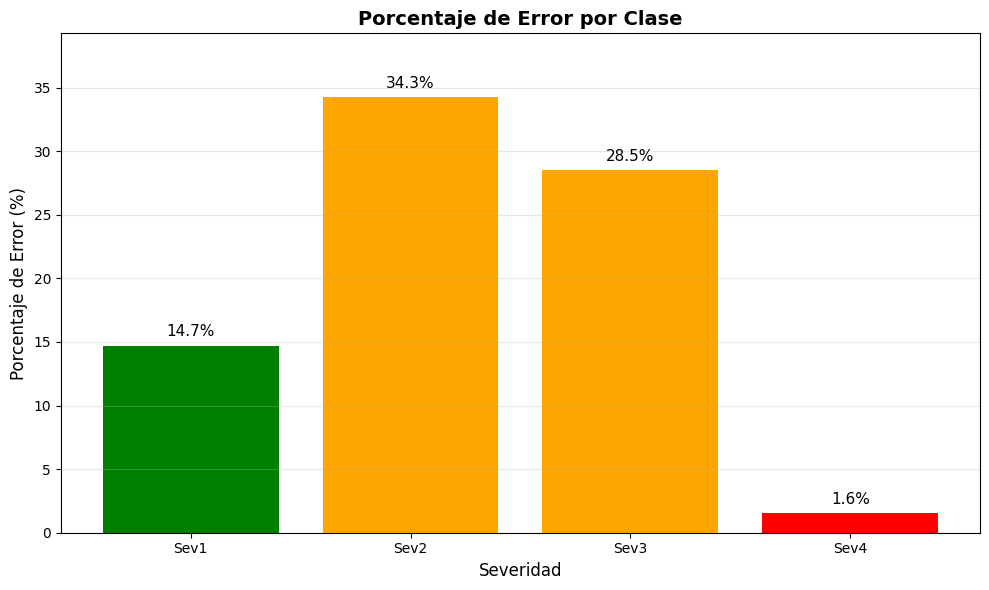

In [ ]:
# XGBOOST

print("="*80)
print(" XGBOOST EXTREMO")
print("="*80)

# 1. AUMENTAR DATOS DE ENTRENAMIENTO (usar 90% en lugar de 80%)

print("\n PASO 1: Aumentando datos de entrenamiento a 90%...")

# Usar 90% para entrenamiento, 10% para prueba (más datos = mejor modelo)
X_train_ext, X_test_ext, y_train_ext, y_test_ext = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42  # Solo 10% test
)

print(f"   Entrenamiento: {len(X_train_ext):,} muestras (90%)")
print(f"   Prueba: {len(X_test_ext):,} muestras (10%)")


# 2. PESOS PARA CLASES DIFÍCILES

print("\n PASO 2: Aplicando pesos para Sev2 y Sev3")

# Calcular pesos basados en distribución inversa
distribucion = np.bincount(y_train_ext)
pesos_clase = {
    0: 0.3,   # Sev1: reducir (ya predice bien)
    1: 5.0,   # Sev2: 5x peso (más difícil)
    2: 5.0,   # Sev3: 5x peso (más difícil)
    3: 0.3    # Sev4: reducir (ya predice excelente)
}

sample_weights = np.array([pesos_clase[y] for y in y_train_ext])

print(f"   Pesos por clase: {pesos_clase}")
print(f"   Peso total: {sample_weights.sum():.0f}")


# 3. XGBOOST CON HIPERPARÁMETROS

print("\n PASO 3: Configurando XGBoost ")

xgb_extremo = xgb.XGBClassifier(
    n_estimators=500,           # Máximo de árboles
    max_depth=10,               # Mayor profundidad
    learning_rate=0.03,         # Tasa baja para aprender mejor
    subsample=0.9,              # Usar 90% de datos por árbol
    colsample_bytree=0.9,       # Usar 90% de features por árbol
    reg_lambda=0.5,             # Menor regularización
    reg_alpha=0.2,              # Menor regularización
    min_child_weight=1,         # Mínimo de muestras por hoja
    scale_pos_weight=1,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

print(f"   n_estimators: 500 (máximo)")
print(f"   max_depth: 10 (profundidad alta)")
print(f"   learning_rate: 0.03 (aprendizaje fino)")


# 4. ENTRENAMIENTO CON EARLY STOPPING

print("\n PASO 4: Entrenando con early stopping...")

# Early stopping para evitar overfitting
eval_set = [(X_train_ext, y_train_ext), (X_test_ext, y_test_ext)]

xgb_extremo.fit(
    X_train_ext, y_train_ext,
    sample_weight=sample_weights,
    eval_set=eval_set,
    verbose=False
)


# 5. EVALUACIÓN

print("\n PASO 5: Evaluando modelo...")

y_pred = xgb_extremo.predict(X_test_ext)
y_pred_proba = xgb_extremo.predict_proba(X_test_ext)

acc = accuracy_score(y_test_ext, y_pred)
f1 = f1_score(y_test_ext, y_pred, average='macro')
f1_per_class = f1_score(y_test_ext, y_pred, average=None)

print("\n" + "="*70)
print(" RESULTADOS ")
print("="*70)
print(f" ACCURACY: {acc:.4f} ({acc*100:.2f}%)")
print(f" F1-SCORE MACRO: {f1:.4f} ({f1*100:.2f}%)")
print(f" F1 por clase: Sev1={f1_per_class[0]:.3f}, Sev2={f1_per_class[1]:.3f}, Sev3={f1_per_class[2]:.3f}, Sev4={f1_per_class[3]:.3f}")

print("\n REPORTE POR CLASE:")
print(classification_report(y_test_ext, y_pred, target_names=['Sev1', 'Sev2', 'Sev3', 'Sev4']))


# 6. MATRIZ DE CONFUSIÓN

cm = confusion_matrix(y_test_ext, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Sev1', 'Sev2', 'Sev3', 'Sev4'],
            yticklabels=['Sev1', 'Sev2', 'Sev3', 'Sev4'])
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.title(f'XGBoost Extremo - Matriz de Confusión\nAccuracy={acc:.3f} | F1={f1:.3f}', fontsize=14)
plt.tight_layout()
plt.show()


# 7. GRÁFICO DE ERRORES POR CLASE

errores = []
for i in range(4):
    total = np.sum(y_test_ext == i)
    aciertos = cm[i, i]
    error_pct = (total - aciertos) / total * 100
    errores.append(error_pct)

plt.figure(figsize=(10, 6))
barras = plt.bar(['Sev1', 'Sev2', 'Sev3', 'Sev4'], errores, color=['green', 'orange', 'orange', 'red'])
plt.ylabel('Porcentaje de Error (%)', fontsize=12)
plt.xlabel('Severidad', fontsize=12)
plt.title('Porcentaje de Error por Clase', fontsize=14, fontweight='bold')

for bar, error in zip(barras, errores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{error:.1f}%', ha='center', va='bottom', fontsize=11)

plt.ylim(0, max(errores) + 5)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()




#PCA


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# features seleccionadas
features_pca = [
    'DayOfWeek',
    'Year',
    'IsWeekend',
    'Latitude',
    'Longitude',
    'State',
    'Distance(mi)',
    'Weather',
    'Has_TrafficSignal',
    'Fatal_Count'
]

# desde dataframe original
X_pca = df_final[features_pca].copy()
y_pca = df_final['Severity'].copy()


# codificar categóricas
cat_cols = ['State', 'Weather']

encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

X_pca[cat_cols] = encoder.fit_transform(
    X_pca[cat_cols]
)

# nulos
X_pca = X_pca.fillna(-1)


# PCA
pca = PCA(
    n_components=0.95,
    random_state=42
)

X_pca_reduced = pca.fit_transform(X_pca)

print("Shape original:", X_pca.shape)
print("Shape PCA:", X_pca_reduced.shape)

print(
    f"Varianza explicada acumulada: "
    f"{pca.explained_variance_ratio_.sum():.4f}"
)

Shape original: (3076766, 10)
Shape PCA: (3076766, 2)
Varianza explicada acumulada: 0.9977


#Varianza

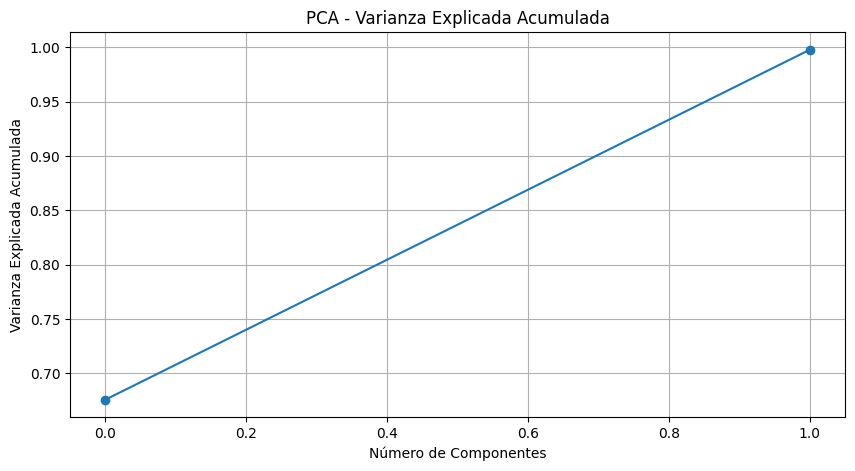

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    np.cumsum(
        pca.explained_variance_ratio_
    ),
    marker='o'
)

plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')

plt.title(
    'PCA - Varianza Explicada Acumulada'
)

plt.grid(True)

plt.show()

#Random Forest + StratifiedKFold sobre PCA

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

# ── Muestra estratificada para que sea ejecutable ──
SAMPLE = 100_000
rng = np.random.default_rng(42)
idx = rng.choice(len(X_pca_reduced), SAMPLE, replace=False)

X_rf = X_pca_reduced[idx]
y_rf = y_pca.iloc[idx].values

print(f"Muestra: {SAMPLE:,} filas | {X_rf.shape[1]} componentes PCA")

rf_pca = RandomForestClassifier(
    n_estimators=277,
    max_depth=7,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1        # solo aquí, no en cross_val_score
)

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Entrenando Random Forest sobre PCA (5-fold)...")

rf_pca_scores = cross_val_score(
    rf_pca,
    X_rf,
    y_rf,
    cv=skf,
    scoring='f1_macro',
    n_jobs=1         # 1 aquí para evitar conflicto con el n_jobs del RF
)

print("\nResultados por fold:")
for i, score in enumerate(rf_pca_scores, 1):
    print(f"  Fold {i}: {score:.4f}")

print(f"\nF1 Macro promedio: {rf_pca_scores.mean():.4f}")
print(f"Desviación estándar: {rf_pca_scores.std():.4f}")

Muestra: 100,000 filas | 2 componentes PCA
Entrenando Random Forest sobre PCA (5-fold)...

Resultados por fold:
  Fold 1: 0.7341
  Fold 2: 0.7379
  Fold 3: 0.7300
  Fold 4: 0.7307
  Fold 5: 0.7309

F1 Macro promedio: 0.7327
Desviación estándar: 0.0029


#Tsnet


   PCA vs t-SNE — Comparación visual 2D
  Features originales:      10
  Componentes PCA (95%):    2
  Varianza explicada total: 0.9977
  Muestra para comparación: 15,000 puntos

  [1/2] Proyectando PCA a 2D (PC1 y PC2)...
  PC1 varianza: 67.6%  |  PC2 varianza: 32.2%
  Total visualizado: 99.8% de la varianza

  [2/2] t-SNE sobre 2 componentes PCA (≈2-4 min)...
  Listo en 3.3 min


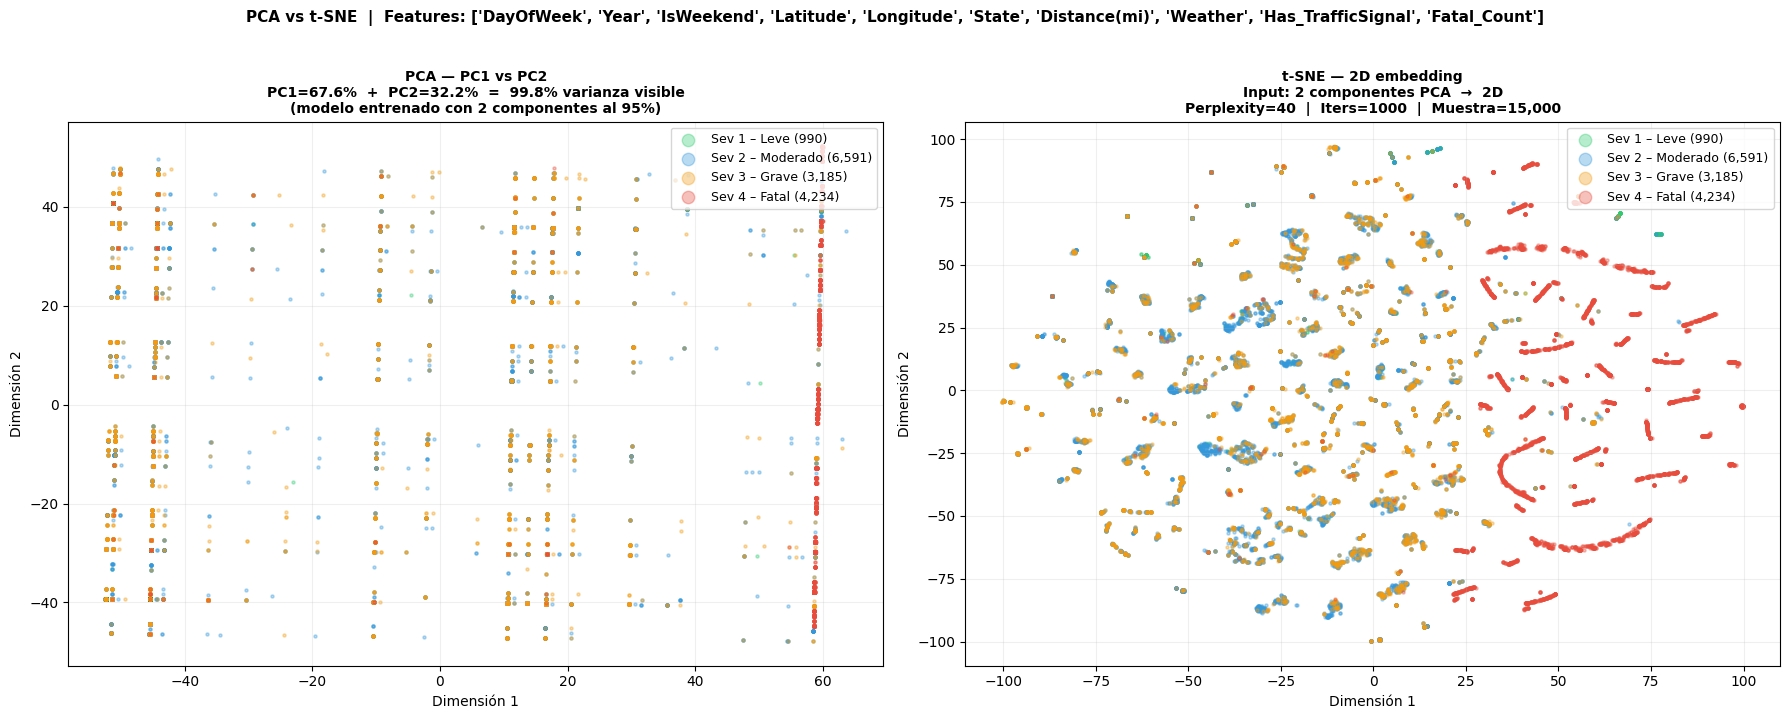


  Separabilidad por clase:
                                ── PCA 2D ──              ── t-SNE 2D ──      
  Severidad                  Centro X     Centro Y     Centro X     Centro Y
  ──────────────────────────────────────────────────────────────────
  Sev 1 – Leve                -26.880       33.815      -28.918       55.134
  Sev 2 – Moderado            -23.359       -2.261      -22.016       -3.156
  Sev 3 – Grave               -19.598       -6.575      -18.758       -6.324
  Sev 4 – Fatal                57.948       -0.141       53.803       -1.740

  Distancia Sev1 ↔ Sev4 (más extremas):
  PCA  : 91.371
  t-SNE: 100.386
  → t-SNE separa mejor las clases extremas en 2D

  Cómo leer la comparación:
  • PCA usa PC1+PC2 de tu modelo (99.8% varianza) → lineal, rápido
  • t-SNE recibió tus 2 componentes PCA → no lineal, preserva vecindades
  • Nubes bien separadas → el modelo distingue esas clases fácilmente
  • Sev 2 y Sev 3 mezcladas → confirma por qué el modelo las confunde
  • Fea

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import time

print("=" * 55)
print("   PCA vs t-SNE — Comparación visual 2D")
print("=" * 55)

# ── Usa exactamente las variables de tu PCA ──
# X_pca_reduced → ya tiene 95% varianza explicada
# y_pca         → Severity original
# features_pca  → las 10 features que definiste
# pca           → el objeto PCA ya entrenado

SAMPLE = 15_000
rng = np.random.default_rng(42)
idx = rng.choice(len(X_pca_reduced), SAMPLE, replace=False)

X_in = X_pca_reduced[idx]       # input compartido: tu PCA reducido
y_in = y_pca.iloc[idx].values   # severidades correspondientes

print(f"  Features originales:      {len(features_pca)}")
print(f"  Componentes PCA (95%):    {X_pca_reduced.shape[1]}")
print(f"  Varianza explicada total: {pca.explained_variance_ratio_.sum():.4f}")
print(f"  Muestra para comparación: {SAMPLE:,} puntos")

# ── PCA → 2D (proyectar las 2 primeras componentes ya calculadas) ──
# No recalculamos PCA, usamos directamente las 2 primeras PCs
print("\n  Proyectando PCA a 2D (PC1 y PC2)...")
X_pca_2d = X_in[:, :2]   # primeras 2 componentes de tu PCA existente
var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100
print(f"  PC1 varianza: {var_pc1:.1f}%  |  PC2 varianza: {var_pc2:.1f}%")
print(f"  Total visualizado: {var_pc1 + var_pc2:.1f}% de la varianza")

# ── t-SNE → 2D (recibe el PCA completo como input) ──
print(f"\n t-SNE sobre {X_pca_reduced.shape[1]} componentes PCA...")
t0 = time.time()
tsne = TSNE(
    n_components=2,
    perplexity=40,
    learning_rate=200,
    n_iter=1000,
    random_state=42,
    n_jobs=-1
)
X_tsne_2d = tsne.fit_transform(X_in)
elapsed = time.time() - t0
print(f"  Listo en {elapsed/60:.1f} min")

# ── Paleta por Severidad ──
COLORES   = {1: '#2ECC71', 2: '#3498DB', 3: '#F39C12', 4: '#E74C3C'}
ETIQUETAS = {1: 'Sev 1 – Leve', 2: 'Sev 2 – Moderado',
             3: 'Sev 3 – Grave', 4: 'Sev 4 – Fatal'}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(
    f'PCA vs t-SNE  |  Features: {features_pca}',
    fontsize=11, fontweight='bold', y=1.02
)

subtitulos = [
    (X_pca_2d,  'PCA — PC1 vs PC2',
     f'PC1={var_pc1:.1f}%  +  PC2={var_pc2:.1f}%  =  {var_pc1+var_pc2:.1f}% varianza visible\n'
     f'(modelo entrenado con {X_pca_reduced.shape[1]} componentes al 95%)'),
    (X_tsne_2d, 't-SNE — 2D embedding',
     f'Input: {X_pca_reduced.shape[1]} componentes PCA  →  2D\n'
     f'Perplexity=40  |  Iters=1000  |  Muestra={SAMPLE:,}')
]

for ax, (X_2d, titulo, subtitulo) in zip(axes, subtitulos):
    for sev in [1, 2, 3, 4]:
        mask = y_in == sev
        if mask.sum() == 0:
            continue
        ax.scatter(
            X_2d[mask, 0], X_2d[mask, 1],
            c=COLORES[sev],
            label=f'{ETIQUETAS[sev]} ({mask.sum():,})',
            alpha=0.35, s=5, rasterized=True
        )
    ax.set_title(f'{titulo}\n{subtitulo}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Dimensión 1')
    ax.set_ylabel('Dimensión 2')
    ax.legend(markerscale=4, fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# ── Tabla de separabilidad: centroides en cada espacio ──
print(f"\n  Separabilidad por clase:")
print(f"  {'':22} {'── PCA 2D ──':^26} {'── t-SNE 2D ──':^26}")
print(f"  {'Severidad':<22} {'Centro X':>12} {'Centro Y':>12} {'Centro X':>12} {'Centro Y':>12}")
print("  " + "─" * 66)

for sev in [1, 2, 3, 4]:
    mask = y_in == sev
    if mask.sum() == 0:
        continue
    px = X_pca_2d[mask, 0].mean()
    py = X_pca_2d[mask, 1].mean()
    tx = X_tsne_2d[mask, 0].mean()
    ty = X_tsne_2d[mask, 1].mean()
    print(f"  {ETIQUETAS[sev]:<22} {px:>12.3f} {py:>12.3f} {tx:>12.3f} {ty:>12.3f}")

# ── Distancia entre centroides Sev1 y Sev4 (más extremas) ──
mask1 = y_in == 1
mask4 = y_in == 4

if mask1.sum() > 0 and mask4.sum() > 0:
    dist_pca = np.sqrt(
        (X_pca_2d[mask1, 0].mean() - X_pca_2d[mask4, 0].mean())**2 +
        (X_pca_2d[mask1, 1].mean() - X_pca_2d[mask4, 1].mean())**2
    )
    dist_tsne = np.sqrt(
        (X_tsne_2d[mask1, 0].mean() - X_tsne_2d[mask4, 0].mean())**2 +
        (X_tsne_2d[mask1, 1].mean() - X_tsne_2d[mask4, 1].mean())**2
    )
    print(f"\n  Distancia Sev1 ↔ Sev4 (más extremas):")
    print(f"  PCA  : {dist_pca:.3f}")
    print(f"  t-SNE: {dist_tsne:.3f}")
    mejor = 't-SNE' if dist_tsne > dist_pca else 'PCA'
    print(f"  → {mejor} separa mejor las clases extremas en 2D")

print(f"""
  Cómo leer la comparación:
  • PCA usa PC1+PC2 de tu modelo ({var_pc1+var_pc2:.1f}% varianza) → lineal, rápido
  • t-SNE recibió tus {X_pca_reduced.shape[1]} componentes PCA → no lineal, preserva vecindades
  • Nubes bien separadas → el modelo distingue esas clases fácilmente
  • Sev 2 y Sev 3 mezcladas → confirma por qué el modelo las confunde
  • Features usadas: {', '.join(features_pca)}
""")

#Kmeans

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

print("Buscando K óptimo con Silhouette Score...")

# muestra para acelerar
sample_size = min(30000, len(X_pca_reduced))

sample_idx = np.random.choice(
    len(X_pca_reduced),
    sample_size,
    replace=False
)

X_cluster = X_pca_reduced[sample_idx]
y_cluster = y_pca.iloc[sample_idx]


# probar K
k_values = range(2, 9)

silhouette_scores = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(
        X_cluster
    )

    score = silhouette_score(
        X_cluster,
        labels
    )

    silhouette_scores.append(score)

    print(
        f"K={k} → Silhouette={score:.4f}"
    )


best_k = k_values[
    np.argmax(silhouette_scores)
]

print(f"\nMejor K encontrado: {best_k}")

Buscando K óptimo con Silhouette Score...
K=2 → Silhouette=0.5229
K=3 → Silhouette=0.5430
K=4 → Silhouette=0.5723
K=5 → Silhouette=0.6088
K=6 → Silhouette=0.6527
K=7 → Silhouette=0.6344
K=8 → Silhouette=0.6294

Mejor K encontrado: 6


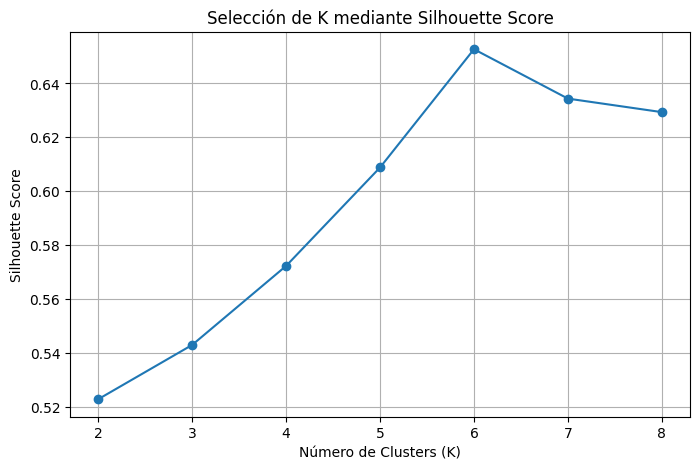

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    silhouette_scores,
    marker='o'
)

plt.xlabel('Número de Clusters (K)')
plt.ylabel('Silhouette Score')

plt.title(
    'Selección de K mediante Silhouette Score'
)

plt.grid(True)

plt.show()

In [ ]:
kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_final.fit_predict(
    X_cluster
)

print("Clustering final completado.")

Clustering final completado.


In [ ]:
import pandas as pd

comparison_df = pd.DataFrame({
    'Cluster': cluster_labels,
    'Severity': y_cluster.values
})

cluster_vs_severity = pd.crosstab(
    comparison_df['Cluster'],
    comparison_df['Severity'],
    normalize='index'
)

display(
    cluster_vs_severity
)

Severity,1.0,2.0,3.0,4.0
Cluster,,,,
0,0.043193,0.032139,0.016172,0.908495
1,0.020151,0.629427,0.343755,0.006668
2,0.209748,0.583069,0.201750,0.005432
3,0.010591,0.578874,0.404125,0.006410
4,0.001382,0.045371,0.032934,0.920313
5,0.064846,0.647414,0.281439,0.006301


<Figure size 1200x600 with 0 Axes>

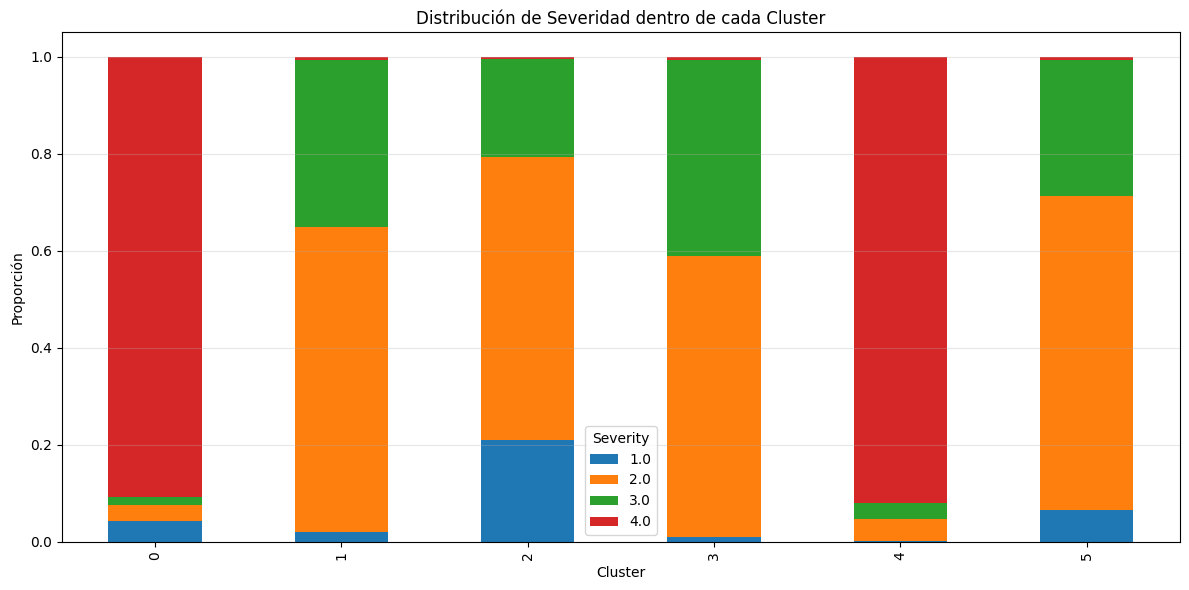

In [ ]:
plt.figure(figsize=(12,6))

cluster_vs_severity.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title(
    'Distribución de Severidad dentro de cada Cluster'
)

plt.xlabel('Cluster')
plt.ylabel('Proporción')

plt.legend(
    title='Severity'
)

plt.grid(
    axis='y',
    alpha=0.3
)

plt.tight_layout()
plt.show()

#Dbscam

   DBSCAN — Clustering por densidad
  Muestra: 20,000 filas | Dims: 2 PCs
  Epsilon automático (codo k-dist): 0.300
  Tiempo: 0.6s
  Clústeres encontrados: 1
  Ruido (outliers):      0 (0.0%)
  Puntos asignados:      20,000
  (Silhouette omitido: clusters insuficientes)


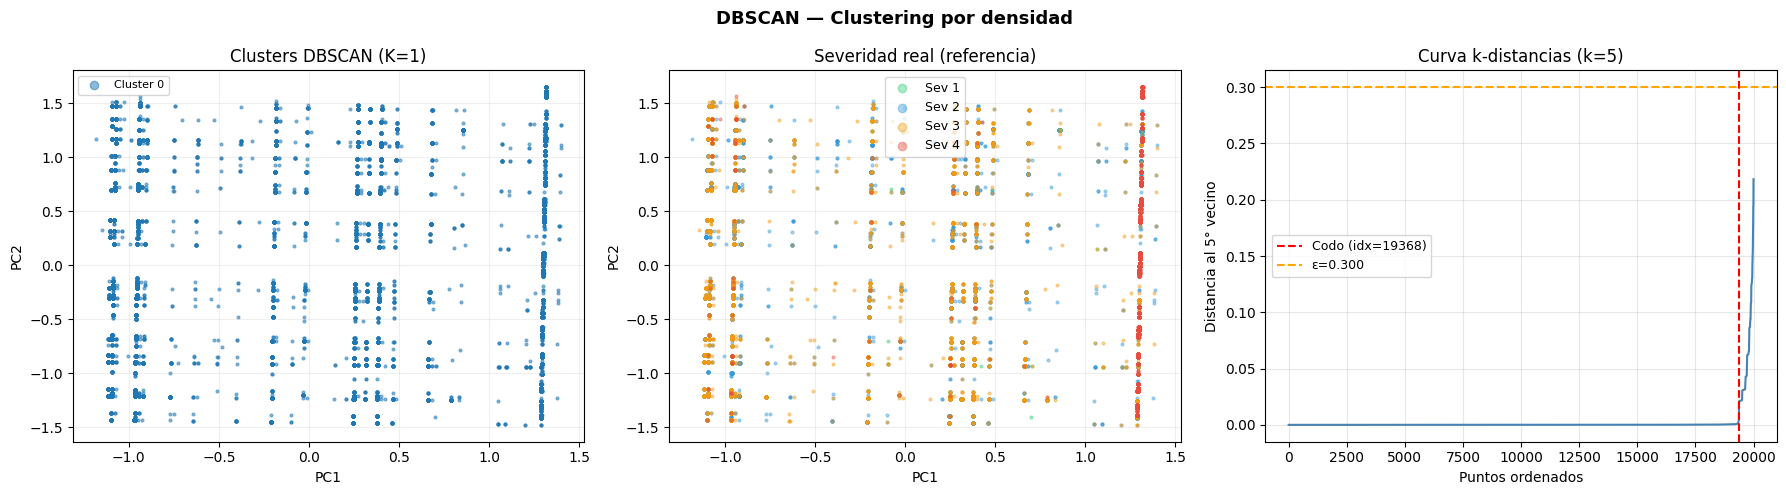


  Resumen DBSCAN:
  Métrica                             Valor
  ------------------------------------------
  Epsilon (ε)                         0.300
  Min samples                            10
  Clústeres hallados                      1
  Puntos ruido                            0

  Interpretación ARI:
  0.0 → asignación aleatoria | 1.0 → coincidencia perfecta con clases reales


In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import time

print("=" * 55)
print("   DBSCAN — Clustering por densidad")
print("=" * 55)

# ── Muestra pequeña: DBSCAN es O(n²) en memoria ──
DBSCAN_SAMPLE = 20_000
rng = np.random.default_rng(42)
idx_db = rng.choice(len(X_pca_reduced), DBSCAN_SAMPLE, replace=False)

X_db = X_pca_reduced[idx_db]
y_db = y_pca.iloc[idx_db].values

# Solo primeras 2 PCs para velocidad (evita maldición dimensionalidad)
X_db_2d = X_db[:, :2]

# Escalar (DBSCAN es sensible a escala)
scaler_db = StandardScaler()
X_db_scaled = scaler_db.fit_transform(X_db_2d)

print(f"  Muestra: {DBSCAN_SAMPLE:,} filas | Dims: 2 PCs")

# ── Búsqueda rápida de epsilon ──
from sklearn.neighbors import NearestNeighbors

k_nn = 5
nbrs = NearestNeighbors(n_neighbors=k_nn, n_jobs=-1).fit(X_db_scaled)
distances, _ = nbrs.kneighbors(X_db_scaled)
k_distances = np.sort(distances[:, -1])

# Epsilon automático: codo de la curva k-distancias
diffs   = np.diff(k_distances)
codo_idx = np.argmax(diffs)
eps_auto = float(k_distances[codo_idx])
eps_auto = max(0.3, min(eps_auto, 1.5))   # clamp razonable
print(f"  Epsilon automático (codo k-dist): {eps_auto:.3f}")

# ── Ejecutar DBSCAN ──
t0 = time.time()
db = DBSCAN(eps=eps_auto, min_samples=10, n_jobs=-1)
labels_db = db.fit_predict(X_db_scaled)
elapsed = time.time() - t0

n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise    = (labels_db == -1).sum()
n_valid    = (labels_db != -1).sum()

print(f"  Tiempo: {elapsed:.1f}s")
print(f"  Clústeres encontrados: {n_clusters}")
print(f"  Ruido (outliers):      {n_noise:,} ({n_noise/DBSCAN_SAMPLE*100:.1f}%)")
print(f"  Puntos asignados:      {n_valid:,}")

# Silhouette solo si hay al menos 2 clusters y no todo es ruido
if n_clusters >= 2 and n_valid > 100:
    sil_idx = np.where(labels_db != -1)[0]
    sil_sample = min(10_000, len(sil_idx))
    sil_pick   = np.random.choice(sil_idx, sil_sample, replace=False)
    sil_db = silhouette_score(X_db_scaled[sil_pick], labels_db[sil_pick])
    ari_db = adjusted_rand_score(y_db[sil_pick], labels_db[sil_pick])
    print(f"  Silhouette Score:      {sil_db:.4f}")
    print(f"  ARI vs Severidad real: {ari_db:.4f}")
else:
    sil_db = None
    print("  (Silhouette omitido: clusters insuficientes)")

# ── Visualización ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('DBSCAN — Clustering por densidad', fontsize=13, fontweight='bold')

# Paleta dinámica
unique_labels = sorted(set(labels_db))
cmap_db = plt.cm.get_cmap('tab10', max(n_clusters, 1))

# Panel 1: Clusters DBSCAN
ax = axes[0]
for lab in unique_labels:
    mask = labels_db == lab
    color = 'black' if lab == -1 else cmap_db(lab % 10)
    lname = 'Ruido' if lab == -1 else f'Cluster {lab}'
    alpha = 0.2 if lab == -1 else 0.5
    ax.scatter(X_db_scaled[mask, 0], X_db_scaled[mask, 1],
               c=[color], label=lname, alpha=alpha, s=4, rasterized=True)
ax.set_title(f'Clusters DBSCAN (K={n_clusters})')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
if n_clusters <= 8:
    ax.legend(markerscale=3, fontsize=8)
ax.grid(True, alpha=0.2)

# Panel 2: Severidad real (mismo espacio)
COLORES = {1: '#2ECC71', 2: '#3498DB', 3: '#F39C12', 4: '#E74C3C'}
ax = axes[1]
for sev in [1, 2, 3, 4]:
    mask = y_db == sev
    ax.scatter(X_db_scaled[mask, 0], X_db_scaled[mask, 1],
               c=COLORES[sev], label=f'Sev {sev}', alpha=0.4, s=4, rasterized=True)
ax.set_title('Severidad real (referencia)')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(markerscale=3, fontsize=9)
ax.grid(True, alpha=0.2)

# Panel 3: Curva k-distancias con epsilon marcado
ax = axes[2]
ax.plot(k_distances, linewidth=1.5, color='steelblue')
ax.axvline(codo_idx, color='red', linestyle='--', label=f'Codo (idx={codo_idx})')
ax.axhline(eps_auto, color='orange', linestyle='--', label=f'ε={eps_auto:.3f}')
ax.set_title(f'Curva k-distancias (k={k_nn})')
ax.set_xlabel('Puntos ordenados'); ax.set_ylabel(f'Distancia al {k_nn}° vecino')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dbscan_resultado.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Resumen ──
print("\n  Resumen DBSCAN:")
print(f"  {'Métrica':<30} {'Valor':>10}")
print("  " + "-" * 42)
print(f"  {'Epsilon (ε)':<30} {eps_auto:>10.3f}")
print(f"  {'Min samples':<30} {'10':>10}")
print(f"  {'Clústeres hallados':<30} {n_clusters:>10}")
print(f"  {'Puntos ruido':<30} {n_noise:>10,}")
if sil_db is not None:
    print(f"  {'Silhouette Score':<30} {sil_db:>10.4f}")
    print(f"  {'ARI vs Severidad':<30} {ari_db:>10.4f}")
print("\n  Interpretación ARI:")
print("  0.0 → asignación aleatoria | 1.0 → coincidencia perfecta con clases reales")

   Agglomerative Clustering — Jerárquico ascendente
  Muestra: 10,000 filas | Dims: 2 PCs
  Probando K...
  K=2  Silhouette=0.3896  (12.2s)
  K=3  Silhouette=0.4529  (5.5s)
  K=4  Silhouette=0.5325  (4.6s)
  K=5  Silhouette=0.5499  (5.8s)
  K=6  Silhouette=0.5460  (6.4s)

  Mejor K: 5  (Silhouette=0.5499)
  ARI vs Severidad real: 0.1935


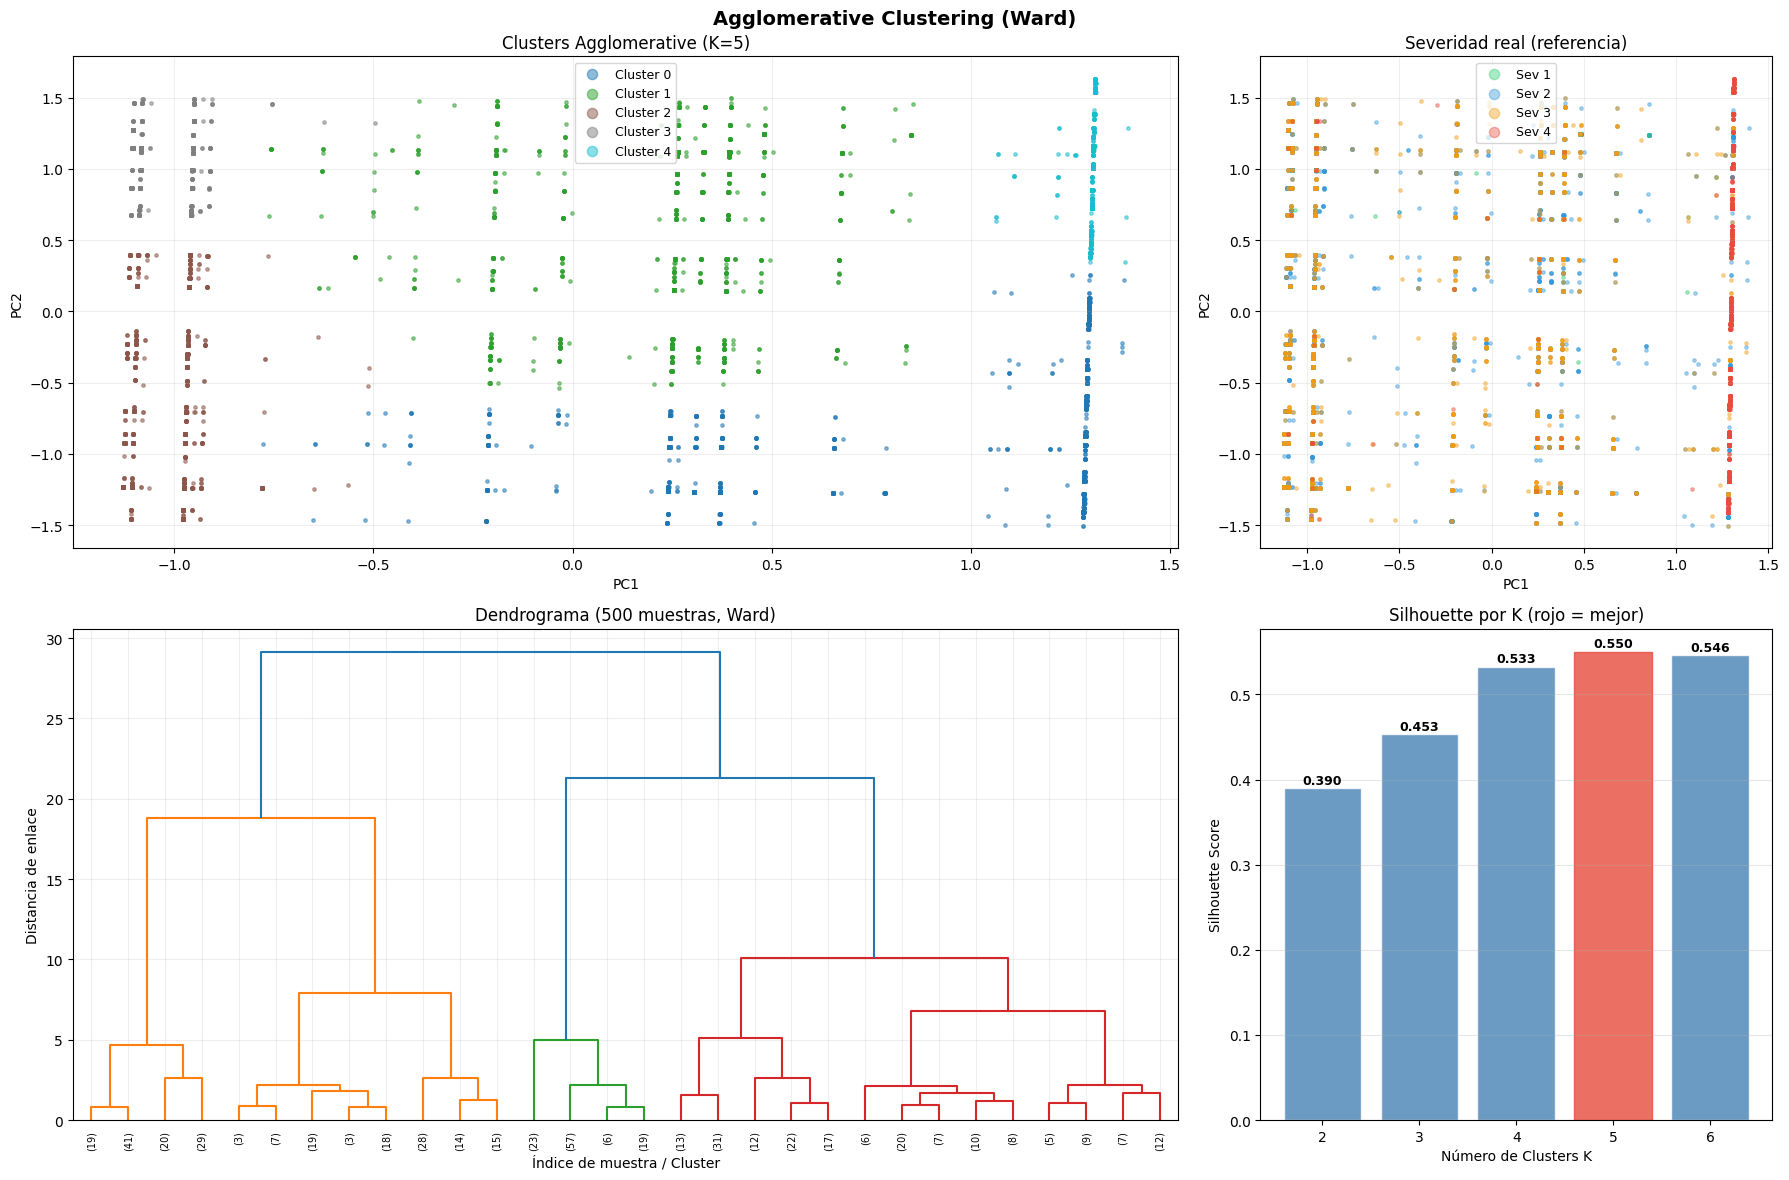


  Composición de clústeres vs Severidad real:
  Cluster        Sev 1     Sev 2     Sev 3     Sev 4     Total   Sev dominante
  -----------------------------------------------------------------
  Cluster 0       15( 0.6%)    634(24.3%)    436(16.7%)  1,523(58.4%)    2,608  Sev 4
  Cluster 1       92( 5.6%)  1,025(62.6%)    511(31.2%)     10( 0.6%)    1,638  Sev 2
  Cluster 2       50( 1.9%)  1,681(64.7%)    855(32.9%)     13( 0.5%)    2,599  Sev 2
  Cluster 3      483(26.7%)    988(54.7%)    325(18.0%)     11( 0.6%)    1,807  Sev 2
  Cluster 4       35( 2.6%)     37( 2.7%)     26( 1.9%)  1,250(92.7%)    1,348  Sev 4

  ARI (Agglomerative vs Severidad): 0.1935
  Silhouette Score (K=5):        0.5499


In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import numpy as np
import time

print("=" * 55)
print("   Agglomerative Clustering — Jerárquico ascendente")
print("=" * 55)

# ── Muestra: Agglomerative es O(n² log n), mantenerla pequeña ──
AGG_SAMPLE = 10_000
rng = np.random.default_rng(42)
idx_agg = rng.choice(len(X_pca_reduced), AGG_SAMPLE, replace=False)

X_agg    = X_pca_reduced[idx_agg, :2]   # 2 primeras PCs
y_agg    = y_pca.iloc[idx_agg].values

from sklearn.preprocessing import StandardScaler
scaler_agg = StandardScaler()
X_agg_scaled = scaler_agg.fit_transform(X_agg)

print(f"  Muestra: {AGG_SAMPLE:,} filas | Dims: 2 PCs")

# ── Probar K = 2..6 y elegir mejor Silhouette ──
k_range   = range(2, 7)
sil_scores_agg = []

print("  Probando K...")
for k in k_range:
    t0  = time.time()
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    lbs = agg.fit_predict(X_agg_scaled)
    sil = silhouette_score(X_agg_scaled, lbs, sample_size=5000, random_state=42)
    sil_scores_agg.append(sil)
    print(f"  K={k}  Silhouette={sil:.4f}  ({time.time()-t0:.1f}s)")

best_k_agg = list(k_range)[np.argmax(sil_scores_agg)]
best_sil   = max(sil_scores_agg)
print(f"\n  Mejor K: {best_k_agg}  (Silhouette={best_sil:.4f})")

# ── Modelo final con mejor K ──
agg_final  = AgglomerativeClustering(n_clusters=best_k_agg, linkage='ward')
labels_agg = agg_final.fit_predict(X_agg_scaled)
ari_agg    = adjusted_rand_score(y_agg, labels_agg)
print(f"  ARI vs Severidad real: {ari_agg:.4f}")

# ── Dendrograma (sobre sub-muestra de 500 para que sea legible) ──
idx_dend  = np.random.choice(AGG_SAMPLE, 500, replace=False)
X_dend    = X_agg_scaled[idx_dend]
Z         = linkage(X_dend, method='ward')

# ── Visualización ──
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Agglomerative Clustering (Ward)', fontsize=14, fontweight='bold')

# Grilla: 2 filas x 3 columnas
ax1 = fig.add_subplot(2, 3, (1, 2))   # Clusters
ax2 = fig.add_subplot(2, 3, 3)        # Severidad real
ax3 = fig.add_subplot(2, 3, (4, 5))   # Dendrograma
ax4 = fig.add_subplot(2, 3, 6)        # Silhouette por K

cmap_agg = plt.cm.get_cmap('tab10', best_k_agg)
COLORES  = {1: '#2ECC71', 2: '#3498DB', 3: '#F39C12', 4: '#E74C3C'}

# Panel 1: Clusters
for k in range(best_k_agg):
    mask = labels_agg == k
    ax1.scatter(X_agg_scaled[mask, 0], X_agg_scaled[mask, 1],
                c=[cmap_agg(k)], label=f'Cluster {k}',
                alpha=0.5, s=6, rasterized=True)
ax1.set_title(f'Clusters Agglomerative (K={best_k_agg})')
ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2')
ax1.legend(markerscale=3, fontsize=9)
ax1.grid(True, alpha=0.2)

# Panel 2: Severidad real
for sev in [1, 2, 3, 4]:
    mask = y_agg == sev
    ax2.scatter(X_agg_scaled[mask, 0], X_agg_scaled[mask, 1],
                c=COLORES[sev], label=f'Sev {sev}',
                alpha=0.4, s=6, rasterized=True)
ax2.set_title('Severidad real (referencia)')
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2')
ax2.legend(markerscale=3, fontsize=9)
ax2.grid(True, alpha=0.2)

# Panel 3: Dendrograma
dendrogram(Z, ax=ax3, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=7, color_threshold=None)
ax3.set_title('Dendrograma (500 muestras, Ward)')
ax3.set_xlabel('Índice de muestra / Cluster')
ax3.set_ylabel('Distancia de enlace')
ax3.grid(True, alpha=0.2)

# Panel 4: Silhouette por K
k_list = list(k_range)
bars = ax4.bar(k_list, sil_scores_agg, color='steelblue', alpha=0.8, edgecolor='white')
bars[np.argmax(sil_scores_agg)].set_color('#E74C3C')
ax4.set_xlabel('Número de Clusters K')
ax4.set_ylabel('Silhouette Score')
ax4.set_title('Silhouette por K (rojo = mejor)')
ax4.set_xticks(k_list)
for bar, val in zip(bars, sil_scores_agg):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('agglomerative_resultado.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Tabla resumen por cluster ──
print("\n  Composición de clústeres vs Severidad real:")
print(f"  {'Cluster':<10}", end='')
for sev in [1, 2, 3, 4]:
    print(f"{'Sev '+str(sev):>10}", end='')
print(f"  {'Total':>8}  {'Sev dominante':>14}")
print("  " + "-" * 65)

for k in range(best_k_agg):
    mask_k   = labels_agg == k
    total_k  = mask_k.sum()
    sev_cnts = [np.sum((labels_agg == k) & (y_agg == s)) for s in [1,2,3,4]]
    dom_sev  = np.argmax(sev_cnts) + 1
    print(f"  Cluster {k:<3}", end='')
    for cnt in sev_cnts:
        pct = cnt / total_k * 100
        print(f"  {cnt:>5,}({pct:>4.1f}%)", end='')
    print(f"  {total_k:>7,}  Sev {dom_sev}")

print(f"\n  ARI (Agglomerative vs Severidad): {ari_agg:.4f}")
print(f"  Silhouette Score (K={best_k_agg}):        {best_sil:.4f}")